# Imports and configs

In [1]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix, classification_report

from scipy.fft import rfft, rfftfreq
from scipy.stats import skew, kurtosis
from scipy.signal import find_peaks
from scipy.spatial.transform import Rotation as R

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.base import clone

from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge
from lightgbm import LGBMClassifier, early_stopping
from xgboost import XGBClassifier

import torch
import torch.nn as nn

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = ['MS Gothic', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

import seaborn as sns
import pandas as pd
import numpy as np
import polars as pl
import warnings
import optuna
import joblib
import glob
import gc
import time
from tqdm import tqdm
import os

warnings.filterwarnings("ignore")

In [2]:
class CFG:
    train_path = "input/train.csv"
    train_demographic_path = "input/train_demographics.csv"
    test_path = "input/test.csv"
    test_demographic_path = "input/test_demographics.csv"

    target = "gesture"
    
    n_folds = 5
    seed = 42

    run_optuna = True
    n_optuna_trials = 100 

# Data loading

In [3]:
train = pd.read_csv(CFG.train_path).reset_index(drop=True)
train_d = pd.read_csv(CFG.train_demographic_path).reset_index(drop=True)
test = pd.read_csv(CFG.test_path).reset_index(drop=True)
test_d = pd.read_csv(CFG.test_demographic_path).reset_index(drop=True)

# Preprocessing

## Base

In [5]:
# Encode target
le_gesture = LabelEncoder()
train["e_gesture"] = le_gesture.fit_transform(train["gesture"])

In [6]:
# rotが欠損しているsequenceは除外
rot_cols = [col for col in train.columns if col.startswith('rot_')]

rot_null_row_train = train[rot_cols].isnull().any(axis=1)
rot_null_sequence_ids_train = train.loc[rot_null_row_train, 'sequence_id'].unique()
rot_null_row_test = test[rot_cols].isnull().any(axis=1)
rot_null_sequence_ids_test = test.loc[rot_null_row_test, 'sequence_id'].unique()

train = train[~train['sequence_id'].isin(rot_null_sequence_ids_train)].reset_index(drop=True)
test = test[~test['sequence_id'].isin(rot_null_sequence_ids_test)].reset_index(drop=True)

print(f"=== rot null sequence count ===")
print(f"train: {len(rot_null_sequence_ids_train)}")
print(f"test: {len(rot_null_sequence_ids_test)}")


=== rot null sequence count ===
train: 50
test: 0


In [7]:
# thm, tofのいずれか1つでもNaNがあればIMU-only
thm_cols = [col for col in train.columns if col.startswith('thm_')]
tof_cols = [col for col in train.columns if col.startswith('tof_')]

thm_null_row_train = train[thm_cols].isnull().any(axis=1)
thm_null_sequence_ids_train = train.loc[thm_null_row_train, 'sequence_id'].unique()

print(f"thm null sequence count: {len(thm_null_sequence_ids_train)}")

tof_null_row_train = train[tof_cols].isnull().any(axis=1)
tof_null_sequence_ids_train = train.loc[tof_null_row_train, 'sequence_id'].unique()

print(f"tof null sequence count: {len(tof_null_sequence_ids_train)}")

imu_only_seq_ids = list(set(thm_null_sequence_ids_train) | set(tof_null_sequence_ids_train))
full_data_seq_ids = train[~train['sequence_id'].isin(imu_only_seq_ids)]['sequence_id'].unique()

# Set thermal and ToF columns to NaN for IMU-only sequences
train.loc[train['sequence_id'].isin(imu_only_seq_ids), thm_cols+tof_cols] = np.nan

print(f"imu only seq count: {len(imu_only_seq_ids)}")
print(f"full data seq count: {len(full_data_seq_ids)}")

thm null sequence count: 508
tof null sequence count: 435
imu only seq count: 508
full data seq count: 7593


In [8]:
# full dataからimu only用のデータを作成
train_imu_only = train.copy()
train_imu_only[thm_cols+tof_cols] = np.nan

train_imu_only.isnull().sum()

row_id                   0
sequence_type            0
sequence_id              0
sequence_counter         0
subject                  0
                     ...  
tof_5_v60           571253
tof_5_v61           571253
tof_5_v62           571253
tof_5_v63           571253
e_gesture                0
Length: 342, dtype: int64

In [9]:
def create_balanced_lightweight_dataset(train, sequences_per_gesture=100):
    """
    各ジェスチャーから指定数のシーケンスをバランス良く抽出
    """
    print("=== バランス軽量化データセット作成 ===")
    
    selected_sequences = []
    gesture_info = []
    
    # 各ジェスチャーから指定数のシーケンスを選択
    for gesture in le_gesture.classes_:
        # 該当ジェスチャーのシーケンスID取得
        gesture_sequences = train[train['gesture'] == gesture]['sequence_id'].unique()
        available_count = len(gesture_sequences)
        
        print(f"{gesture}: {available_count} sequences available")
        
        # 指定数まで選択（利用可能数が少ない場合は全て選択）
        n_to_select = min(sequences_per_gesture, available_count)
        
        # ランダムサンプリング（再現性のため乱数シード固定）
        np.random.seed(CFG.seed)
        selected = np.random.choice(gesture_sequences, n_to_select, replace=False)
        selected_sequences.extend(selected)
        
        gesture_info.append({
            'gesture': gesture,
            'available': available_count,
            'selected': n_to_select
        })
    
    # 選択されたシーケンスでデータを絞り込み
    train_balanced = train[train['sequence_id'].isin(selected_sequences)].copy()
    
    # 結果サマリー
    print(f"\n=== 軽量化結果 ===")
    print(f"総シーケンス数: {len(selected_sequences)}")
    print(f"元データからの削減率: {(1 - len(selected_sequences)/len(train['sequence_id'].unique())):.1%}")
    
    # ジェスチャー別サマリー
    gesture_summary = pd.DataFrame(gesture_info)
    print(f"\nジェスチャー別選択数:")
    for _, row in gesture_summary.iterrows():
        print(f"  {row['gesture']}: {row['selected']}/{row['available']}")
    
    # IMU-only vs Full-sensor比率確認
    imu_sequences = train_balanced[train_balanced['sequence_id'].isin(imu_only_seq_ids)]['sequence_id'].nunique()
    full_sequences = train_balanced[~train_balanced['sequence_id'].isin(imu_only_seq_ids)]['sequence_id'].nunique()
    
    print(f"\n=== センサータイプ分布 ===")
    print(f"IMU-only: {imu_sequences} sequences ({imu_sequences/len(selected_sequences):.1%})")
    print(f"Full-sensor: {full_sequences} sequences ({full_sequences/len(selected_sequences):.1%})")
    
    # 被験者分布確認
    selected_subjects = train_balanced['subject'].nunique()
    total_subjects = train['subject'].nunique()
    print(f"\n=== 被験者分布 ===")
    print(f"対象被験者数: {selected_subjects}/{total_subjects}")
    
    return train_balanced, selected_sequences

In [10]:
# バランス軽量化実行
train_balanced, selected_sequences = create_balanced_lightweight_dataset(
    train, sequences_per_gesture=150
)

=== バランス軽量化データセット作成 ===
Above ear - pull hair: 634 sequences available
Cheek - pinch skin: 633 sequences available
Drink from bottle/cup: 161 sequences available
Eyebrow - pull hair: 634 sequences available
Eyelash - pull hair: 636 sequences available
Feel around in tray and pull out an object: 161 sequences available
Forehead - pull hairline: 636 sequences available
Forehead - scratch: 636 sequences available
Glasses on/off: 161 sequences available
Neck - pinch skin: 636 sequences available
Neck - scratch: 634 sequences available
Pinch knee/leg skin: 161 sequences available
Pull air toward your face: 473 sequences available
Scratch knee/leg skin: 161 sequences available
Text on phone: 636 sequences available
Wave hello: 474 sequences available
Write name in air: 473 sequences available
Write name on leg: 161 sequences available

=== 軽量化結果 ===
総シーケンス数: 2700
元データからの削減率: 66.7%

ジェスチャー別選択数:
  Above ear - pull hair: 150/634
  Cheek - pinch skin: 150/633
  Drink from bottle/cup: 150/161
  E

## ACC/ROT

In [11]:
def remove_gravity_from_acc(acc_data, rot_data):

    if isinstance(acc_data, pd.DataFrame):
        acc_values = acc_data[['acc_x', 'acc_y', 'acc_z']].values
    else:
        acc_values = acc_data

    if isinstance(rot_data, pd.DataFrame):
        quat_values = rot_data[['rot_x', 'rot_y', 'rot_z', 'rot_w']].values
    else:
        quat_values = rot_data

    num_samples = acc_values.shape[0]
    linear_accel = np.zeros_like(acc_values)
    
    gravity_world = np.array([0, 0, 9.81])

    for i in range(num_samples):
        if np.all(np.isnan(quat_values[i])) or np.all(np.isclose(quat_values[i], 0)):
            linear_accel[i, :] = acc_values[i, :] 
            continue

        try:
            rotation = R.from_quat(quat_values[i])
            gravity_sensor_frame = rotation.apply(gravity_world, inverse=True)
            linear_accel[i, :] = acc_values[i, :] - gravity_sensor_frame
        except ValueError:
             linear_accel[i, :] = acc_values[i, :]
             
    return linear_accel

In [12]:
def calculate_angular_velocity_from_quat(rot_data, time_delta=1/200): # Assuming 200Hz sampling rate
    if isinstance(rot_data, pd.DataFrame):
        quat_values = rot_data[['rot_x', 'rot_y', 'rot_z', 'rot_w']].values
    else:
        quat_values = rot_data

    num_samples = quat_values.shape[0]
    angular_vel = np.zeros((num_samples, 3))

    for i in range(num_samples - 1):
        q_t = quat_values[i]
        q_t_plus_dt = quat_values[i+1]

        if np.all(np.isnan(q_t)) or np.all(np.isclose(q_t, 0)) or \
           np.all(np.isnan(q_t_plus_dt)) or np.all(np.isclose(q_t_plus_dt, 0)):
            continue

        try:
            rot_t = R.from_quat(q_t)
            rot_t_plus_dt = R.from_quat(q_t_plus_dt)

            # Calculate the relative rotation
            delta_rot = rot_t.inv() * rot_t_plus_dt
            
            # Convert delta rotation to angular velocity vector
            # The rotation vector (Euler axis * angle) scaled by 1/dt
            # is a good approximation for small delta_rot
            angular_vel[i, :] = delta_rot.as_rotvec() / time_delta
        except ValueError:
            # If quaternion is invalid, angular velocity remains zero
            pass
            
    return angular_vel

In [13]:
def calculate_angular_distance(rot_data):
    if isinstance(rot_data, pd.DataFrame):
        quat_values = rot_data[['rot_x', 'rot_y', 'rot_z', 'rot_w']].values
    else:
        quat_values = rot_data

    num_samples = quat_values.shape[0]
    angular_dist = np.zeros(num_samples)

    for i in range(num_samples - 1):
        q1 = quat_values[i]
        q2 = quat_values[i+1]

        if np.all(np.isnan(q1)) or np.all(np.isclose(q1, 0)) or \
           np.all(np.isnan(q2)) or np.all(np.isclose(q2, 0)):
            angular_dist[i] = 0 # Или np.nan, в зависимости от желаемого поведения
            continue
        try:
            # Преобразование кватернионов в объекты Rotation
            r1 = R.from_quat(q1)
            r2 = R.from_quat(q2)

            # Вычисление углового расстояния: 2 * arccos(|real(p * q*)|)
            # где p* - сопряженный кватернион q
            # В scipy.spatial.transform.Rotation, r1.inv() * r2 дает относительное вращение.
            # Угол этого относительного вращения - это и есть угловое расстояние.
            relative_rotation = r1.inv() * r2
            
            # Угол rotation vector соответствует угловому расстоянию
            # Норма rotation vector - это угол в радианах
            angle = np.linalg.norm(relative_rotation.as_rotvec())
            angular_dist[i] = angle
        except ValueError:
            angular_dist[i] = 0 # В случае недействительных кватернионов
            pass
            
    return angular_dist

In [14]:
def extract_imu_features(df: pd.DataFrame) -> dict:
    """
    IMUセンサ（加速度計・ジャイロスコープ）の特徴量を抽出する関数
    線形加速度と生データの両方から補完的な特徴量を抽出
    重力座標系での動き分析も含む
    """
    feats = {}
    
    # 基本的なIMU列の取得
    base_imu_cols = [c for c in df.columns if any(x in c for x in ['acc_', 'rot_'])]

    # 高度なIMU特徴量の作成
    try:
        # 1. 重力除去による線形加速度（メイン特徴量）
        if all(col in df.columns for col in ['acc_x', 'acc_y', 'acc_z', 'rot_x', 'rot_y', 'rot_z', 'rot_w']):
            acc_data = df[['acc_x', 'acc_y', 'acc_z']]
            rot_data = df[['rot_x', 'rot_y', 'rot_z', 'rot_w']]
            linear_accel = remove_gravity_from_acc(acc_data, rot_data)
            
            # 線形加速度をメインとして使用
            df['linear_acc_x'] = linear_accel[:, 0]
            df['linear_acc_y'] = linear_accel[:, 1]
            df['linear_acc_z'] = linear_accel[:, 2]
            df['linear_acc_mag'] = np.sqrt(linear_accel[:, 0]**2 + linear_accel[:, 1]**2 + linear_accel[:, 2]**2)
            
            # 線形加速度のJerk（より重要）
            df['linear_acc_jerk_x'] = df['linear_acc_x'].diff().fillna(0)
            df['linear_acc_jerk_y'] = df['linear_acc_y'].diff().fillna(0)
            df['linear_acc_jerk_z'] = df['linear_acc_z'].diff().fillna(0)
            df['linear_acc_jerk_mag'] = np.sqrt(df['linear_acc_jerk_x']**2 + df['linear_acc_jerk_y']**2 + df['linear_acc_jerk_z']**2)
            
            # === 重力座標系での動き分析 ===
            # 線形加速度をグローバル座標系に変換
            quat_values = df[['rot_x', 'rot_y', 'rot_z', 'rot_w']].values
            global_acc = np.zeros_like(linear_accel)
            
            for i in range(len(linear_accel)):
                if not np.any(np.isnan(quat_values[i])) and not np.all(np.isclose(quat_values[i], 0)):
                    try:
                        rotation = R.from_quat(quat_values[i])
                        # ローカル座標系からグローバル座標系に変換
                        global_acc[i] = rotation.apply(linear_accel[i])
                    except ValueError:
                        global_acc[i] = linear_accel[i]
                else:
                    global_acc[i] = linear_accel[i]
            
            # グローバル座標系での特徴量をデータフレームに追加
            df['global_acc_x'] = global_acc[:, 0]  # グローバルX軸（左右方向）
            df['global_acc_y'] = global_acc[:, 1]  # グローバルY軸（前後方向）
            df['global_acc_z'] = global_acc[:, 2]  # グローバルZ軸（上下方向）
            df['global_acc_mag'] = np.sqrt(global_acc[:, 0]**2 + global_acc[:, 1]**2 + global_acc[:, 2]**2)
            
            # グローバル座標系でのJerk
            df['global_acc_jerk_x'] = df['global_acc_x'].diff().fillna(0)
            df['global_acc_jerk_y'] = df['global_acc_y'].diff().fillna(0)
            df['global_acc_jerk_z'] = df['global_acc_z'].diff().fillna(0)
            df['global_acc_jerk_mag'] = np.sqrt(df['global_acc_jerk_x']**2 + df['global_acc_jerk_y']**2 + df['global_acc_jerk_z']**2)
            
            # 方向別の動作強度比（重要な位置特徴量）
            total_motion = df['global_acc_mag'].values
            if np.mean(total_motion) > 1e-8:
                feats['vertical_motion_ratio'] = np.mean(np.abs(df['global_acc_z'])) / np.mean(total_motion)  # 上下動作の比率
                feats['horizontal_motion_ratio'] = np.mean(np.sqrt(df['global_acc_x']**2 + df['global_acc_y']**2)) / np.mean(total_motion)  # 水平動作の比率
                feats['lateral_motion_ratio'] = np.mean(np.abs(df['global_acc_x'])) / np.mean(total_motion)  # 左右動作の比率
                feats['forward_motion_ratio'] = np.mean(np.abs(df['global_acc_y'])) / np.mean(total_motion)  # 前後動作の比率
            else:
                feats['vertical_motion_ratio'] = 0
                feats['horizontal_motion_ratio'] = 0
                feats['lateral_motion_ratio'] = 0
                feats['forward_motion_ratio'] = 0
            
            # 重力座標系での方向優勢度
            global_acc_abs = np.abs(global_acc)
            if np.sum(global_acc_abs) > 1e-8:
                feats['x_dominance'] = np.sum(global_acc_abs[:, 0]) / np.sum(global_acc_abs)  # X軸優勢度
                feats['y_dominance'] = np.sum(global_acc_abs[:, 1]) / np.sum(global_acc_abs)  # Y軸優勢度
                feats['z_dominance'] = np.sum(global_acc_abs[:, 2]) / np.sum(global_acc_abs)  # Z軸優勢度
            else:
                feats['x_dominance'] = 0.33
                feats['y_dominance'] = 0.33
                feats['z_dominance'] = 0.33
            
            # メインIMU特徴量として線形加速度＋グローバル加速度を採用
            main_imu_cols = [
                'linear_acc_x', 'linear_acc_y', 'linear_acc_z', 'linear_acc_mag',
                'linear_acc_jerk_x', 'linear_acc_jerk_y', 'linear_acc_jerk_z', 'linear_acc_jerk_mag',
                'global_acc_x', 'global_acc_y', 'global_acc_z', 'global_acc_mag',
                'global_acc_jerk_x', 'global_acc_jerk_y', 'global_acc_jerk_z', 'global_acc_jerk_mag'
            ]
        else:
            # フォールバック: 生データを使用
            df['acc_mag'] = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)
            df['acc_jerk_x'] = df['acc_x'].diff().fillna(0)
            df['acc_jerk_y'] = df['acc_y'].diff().fillna(0)
            df['acc_jerk_z'] = df['acc_z'].diff().fillna(0)
            df['acc_jerk_mag'] = np.sqrt(df['acc_jerk_x']**2 + df['acc_jerk_y']**2 + df['acc_jerk_z']**2)
            
            main_imu_cols = ['acc_x', 'acc_y', 'acc_z', 'acc_mag', 'acc_jerk_x', 'acc_jerk_y', 'acc_jerk_z', 'acc_jerk_mag']

        # 2. 補完的特徴量として生データのMagnitudeも保持（姿勢情報用）
        df['raw_acc_mag'] = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)
        
        # 3. 回転関連は既存を維持
        df['rot_mag'] = np.sqrt(df['rot_x']**2 + df['rot_y']**2 + df['rot_z']**2)
        
        # 角速度計算
        if all(col in df.columns for col in ['rot_x', 'rot_y', 'rot_z', 'rot_w']):
            rot_data = df[['rot_x', 'rot_y', 'rot_z', 'rot_w']]
            angular_velocity = calculate_angular_velocity_from_quat(rot_data)
            
            df['angular_vel_x'] = angular_velocity[:, 0]
            df['angular_vel_y'] = angular_velocity[:, 1]
            df['angular_vel_z'] = angular_velocity[:, 2]
            df['angular_vel_mag'] = np.sqrt(angular_velocity[:, 0]**2 + angular_velocity[:, 1]**2 + angular_velocity[:, 2]**2)
            
            # 角度距離
            angular_distance = calculate_angular_distance(rot_data)
            df['angular_distance'] = angular_distance
            
            # 回転関連特徴量
            rotation_cols = [
                'rot_x', 'rot_y', 'rot_z', 'rot_w', 'rot_mag',
                'angular_vel_x', 'angular_vel_y', 'angular_vel_z', 'angular_vel_mag',
                'angular_distance'
            ]
        else:
            rotation_cols = ['rot_x', 'rot_y', 'rot_z', 'rot_w', 'rot_mag']

        # 全特徴量列を統合
        all_feature_cols = main_imu_cols + rotation_cols + ['raw_acc_mag']
        
        # 姿勢情報特徴量（重力方向に対する傾き）
        feats['gravity_dominance'] = np.mean(df['raw_acc_mag']) - np.mean(df['linear_acc_mag'])  # 重力成分の大きさ
        
    except Exception as e:
        print(f"高度なIMU特徴量作成でエラー: {e}")
        # フォールバック処理
        all_feature_cols = base_imu_cols

    # Feature Extraction for all IMU features
    for col in all_feature_cols:
        if col not in df.columns:
            continue
            
        arr = df[col].values
        
        if np.all(np.isnan(arr)) or len(arr) == 0:
            continue

        # 統計量特徴量
        feats[f'{col}_mean'] = np.nanmean(arr)
        feats[f'{col}_std'] = np.nanstd(arr)
        feats[f'{col}_min'] = np.nanmin(arr)
        feats[f'{col}_max'] = np.nanmax(arr)
        
        # 有効値での追加特徴量
        valid_arr = arr[~np.isnan(arr)]
        if len(valid_arr) > 1:
            # Rolling Window Features
            for window in [10, 20]:
                rolling_mean = df[col].rolling(window=window, min_periods=1).mean()
                feats[f'{col}_roll_mean_{window}_mean'] = rolling_mean.mean()

            # Frequency Domain Features
            fft_vals = rfft(valid_arr)
            fft_mags = np.abs(fft_vals)

            if len(fft_mags) > 1:
                # 従来の最大値
                feats[f'{col}_fft_max'] = np.max(fft_mags)
                
                # 改良: DC成分を除外した最大値
                feats[f'{col}_fft_max_no_dc'] = np.max(fft_mags[1:])  # DC(0Hz)を除外
                
                # 改良: 周波数帯域別の強度
                n_freq = len(fft_mags)
                feats[f'{col}_fft_low'] = np.mean(fft_mags[1:n_freq//4])    # 低周波
                feats[f'{col}_fft_mid'] = np.mean(fft_mags[n_freq//4:n_freq//2])  # 中周波
                feats[f'{col}_fft_high'] = np.mean(fft_mags[n_freq//2:])   # 高周波
                
                # 改良: 周波数分布の偏り
                feats[f'{col}_fft_centroid'] = np.sum(fft_mags * np.arange(len(fft_mags))) / np.sum(fft_mags)

    # 相関関係（線形加速度メイン＋グローバル座標系）
    correlation_pairs = [
        # 線形加速度間の相関（ローカル座標系）
        ('linear_acc_x', 'linear_acc_y'), ('linear_acc_x', 'linear_acc_z'), ('linear_acc_y', 'linear_acc_z'),
        # グローバル座標系での相関
        ('global_acc_x', 'global_acc_y'), ('global_acc_x', 'global_acc_z'), ('global_acc_y', 'global_acc_z'),
        # 線形加速度のJerk間の相関
        ('linear_acc_jerk_x', 'linear_acc_jerk_y'), ('linear_acc_jerk_x', 'linear_acc_jerk_z'), ('linear_acc_jerk_y', 'linear_acc_jerk_z'),
        # グローバルJerk間の相関
        ('global_acc_jerk_x', 'global_acc_jerk_y'), ('global_acc_jerk_x', 'global_acc_jerk_z'), ('global_acc_jerk_y', 'global_acc_jerk_z'),
        # 回転関連
        ('rot_x', 'rot_y'), ('rot_x', 'rot_z'), ('rot_y', 'rot_z'),
        ('angular_vel_x', 'angular_vel_y'), ('angular_vel_x', 'angular_vel_z'), ('angular_vel_y', 'angular_vel_z'),
        # 加速度と回転の関係
        ('linear_acc_mag', 'angular_vel_mag'), ('linear_acc_mag', 'rot_mag'),
        ('global_acc_mag', 'angular_vel_mag'), ('global_acc_mag', 'linear_acc_mag'),
        # 姿勢関連（補完情報）
        ('raw_acc_mag', 'linear_acc_mag'), ('raw_acc_mag', 'global_acc_mag')
    ]
    
    for (c1, c2) in correlation_pairs:
        if c1 in df.columns and c2 in df.columns:
            try:
                valid_mask = ~(np.isnan(df[c1]) | np.isnan(df[c2]))
                if valid_mask.sum() > 1:
                    corr_val = np.corrcoef(df[c1][valid_mask], df[c2][valid_mask])[0, 1]
                    feats[f'{c1}_{c2}_corr'] = corr_val if not np.isnan(corr_val) else 0
                else:
                    feats[f'{c1}_{c2}_corr'] = 0
            except:
                feats[f'{c1}_{c2}_corr'] = 0
    
    return feats

## TOF

In [15]:
def preprocess_tof_for_lstm(df, sequence_id):
    """
    TOFセンサデータをLSTM用に前処理
    """
    # シーケンスデータを抽出
    seq_data = df[df['sequence_id'] == sequence_id]
    
    # TOFセンサーごとにデータを整理
    tof_features = {}
    
    for sensor_id in range(1, 6):  # tof_1 から tof_5
        sensor_cols = [col for col in seq_data.columns if col.startswith(f'tof_{sensor_id}_v')]
        
        if not sensor_cols:
            continue
            
        # センサーデータを抽出（64チャンネル × 時系列長）
        sensor_data = seq_data[sensor_cols].values  # shape: (time_steps, 64)
        
        # 無効値（-1）をNaNに変換
        sensor_data = np.where(sensor_data == -1, np.nan, sensor_data)
        
        # 欠損値の補完（前向き補完）
        sensor_data = pd.DataFrame(sensor_data).fillna(method='ffill').fillna(method='bfill').values
        
        tof_features[f'tof_{sensor_id}'] = sensor_data
    
    return tof_features

In [16]:
class TOFLSTMFeatureExtractor(nn.Module):
    def __init__(self, input_size=64, hidden_size=128, num_layers=2, dropout=0.2, output_size=100):
        super(TOFLSTMFeatureExtractor, self).__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_size,      # 64チャンネル
            hidden_size=hidden_size,    # 隠れ層サイズ
            num_layers=num_layers,      # LSTM層数
            dropout=dropout,
            batch_first=True
        )
        
        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_size,
            num_heads=8,
            dropout=dropout
        )
        
        self.feature_extractor = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, output_size)  # 最終特徴量サイズ
        )
        
    def forward(self, x):
        # x shape: (batch_size, time_steps, 64)
        
        # LSTM処理
        lstm_out, (hidden, cell) = self.lstm(x)
        
        # Attention処理
        lstm_out = lstm_out.transpose(0, 1)  # (time_steps, batch_size, hidden_size)
        attn_out, _ = self.attention(lstm_out, lstm_out, lstm_out)
        attn_out = attn_out.transpose(0, 1)  # (batch_size, time_steps, hidden_size)
        
        # 最終時刻の出力を使用
        final_output = attn_out[:, -1, :]  # (batch_size, hidden_size)
        
        # 特徴量抽出
        features = self.feature_extractor(final_output)
        
        return features

In [17]:
def extract_tof_lstm_features(df, model, device='cpu'):
    """
    LSTMを使用してTOFセンサから特徴量を抽出
    """
    model.eval()
    features = {}
    
    with torch.no_grad():
        for sensor_id in range(1, 6):
            sensor_cols = [col for col in df.columns if col.startswith(f'tof_{sensor_id}_v')]
            
            if not sensor_cols:
                continue
                
            # センサーデータを準備
            sensor_data = df[sensor_cols].values  # (time_steps, 64)
            sensor_data = np.where(sensor_data == -1, np.nan, sensor_data)
            sensor_data = pd.DataFrame(sensor_data).fillna(method='ffill').fillna(method='bfill').values
            
            # 正規化
            sensor_data = (sensor_data - np.mean(sensor_data, axis=0)) / (np.std(sensor_data, axis=0) + 1e-8)
            
            # テンソルに変換
            sensor_tensor = torch.FloatTensor(sensor_data).unsqueeze(0).to(device)  # (1, time_steps, 64)
            
            # LSTM特徴量抽出
            lstm_features = model(sensor_tensor).cpu().numpy().flatten()  # (64,)
            
            # 特徴量を辞書に追加
            for i, feat in enumerate(lstm_features):
                features[f'tof_{sensor_id}_lstm_feat_{i}'] = feat
    
    return features

In [18]:
def extract_tof_features(df, tof_cols) -> dict:
    """
    ToFセンサーの特徴量を抽出する関数
    各センサー（tof_1～tof_5）ごとに10個の特徴量を作成
    
    Parameters:
    -----------
    df : pandas.DataFrame
        データフレーム
    tof_cols : list
        ToF関連の列名リスト
        
    Returns:
    --------
    dict : ToF特徴量の辞書
    """
    feats = {}
    
    # 各ToFセンサー（1-5）ごとに特徴量を作成
    for sensor_id in range(1, 6):
        tof_sensor_cols = [col for col in tof_cols if col.startswith(f'tof_{sensor_id}_v')]
        
        if not tof_sensor_cols:
            continue
            
        # 有効性チェック
        sensor_data = df[tof_sensor_cols].values
        valid_sensor = sensor_data >= 0
        valid_ratio = np.mean(valid_sensor)
        
        # 有効データが少ない場合はデフォルト値を設定
        if valid_ratio < 0.1:
            # デフォルト値（10個）
            feats[f'tof_{sensor_id}_global_mean'] = 0
            feats[f'tof_{sensor_id}_global_std'] = 0
            feats[f'tof_{sensor_id}_valid_ratio'] = 0
            feats[f'tof_{sensor_id}_pixel_min_mean'] = 0
            feats[f'tof_{sensor_id}_pixel_median_mean'] = 0
            feats[f'tof_{sensor_id}_Prepare_mean'] = 0
            feats[f'tof_{sensor_id}_Moving_mean'] = 0
            feats[f'tof_{sensor_id}_At_Target_mean'] = 0
            feats[f'tof_{sensor_id}_Gesture_mean'] = 0
            feats[f'tof_{sensor_id}_gesture_variation'] = 0
            feats[f'tof_{sensor_id}_gesture_trend'] = 0
            feats[f'tof_{sensor_id}_gesture_instability'] = 0
            continue
        
        # 1. センサー全体統計（3特徴量）
        valid_sensor_values = sensor_data[valid_sensor]
        if len(valid_sensor_values) > 0:
            feats[f'tof_{sensor_id}_global_mean'] = np.mean(valid_sensor_values)
            feats[f'tof_{sensor_id}_global_std'] = np.std(valid_sensor_values)
            feats[f'tof_{sensor_id}_valid_ratio'] = valid_ratio

            pixel_mins = []
            pixel_medians = []
            for i in range(sensor_data.shape[1]):  # 各チャンネル
                pixel_data = sensor_data[:, i]
                valid_pixel_data = pixel_data[pixel_data >= 0]
                if len(valid_pixel_data) > 0:
                    pixel_mins.append(np.min(valid_pixel_data))
                    pixel_medians.append(np.median(valid_pixel_data))
            
            feats[f'tof_{sensor_id}_pixel_min_mean'] = np.mean(pixel_mins) if pixel_mins else 0
            feats[f'tof_{sensor_id}_pixel_median_mean'] = np.mean(pixel_medians) if pixel_medians else 0
        else:
            feats[f'tof_{sensor_id}_global_mean'] = 0
            feats[f'tof_{sensor_id}_global_std'] = 0
            feats[f'tof_{sensor_id}_valid_ratio'] = 0
            feats[f'tof_{sensor_id}_pixel_min_mean'] = 0
            feats[f'tof_{sensor_id}_pixel_median_mean'] = 0
        
        # 2. フェーズ別平均統計（4特徴量）
        phases = ['Prepare', 'Moving', 'At_Target', 'Gesture']
        behavior_map = {
            'Relaxes and moves hand to target location': 'Prepare',
            'Moves hand to target location': 'Moving',
            'Hand at target location': 'At_Target',
            'Performs gesture': 'Gesture'
        }
        
        for phase in phases:
            if 'behavior' in df.columns:
                phase_mask = df['behavior'].map(behavior_map) == phase
                if phase_mask.any():
                    phase_sensor_data = sensor_data[phase_mask]
                    phase_valid = phase_sensor_data >= 0
                    phase_valid_values = phase_sensor_data[phase_valid]
                    
                    if len(phase_valid_values) > 0:
                        feats[f'tof_{sensor_id}_{phase}_mean'] = np.mean(phase_valid_values)
                    else:
                        feats[f'tof_{sensor_id}_{phase}_mean'] = 0
                else:
                    feats[f'tof_{sensor_id}_{phase}_mean'] = 0
            else:
                feats[f'tof_{sensor_id}_{phase}_mean'] = 0
        
        # 3. Gestureフェーズの動的特徴（3特徴量）
        if 'behavior' in df.columns:
            gesture_mask = df['behavior'].map(behavior_map) == 'Gesture'
            if gesture_mask.any() and gesture_mask.sum() > 2:
                gesture_variations = []
                gesture_trends = []
                gesture_changes = []
                
                for col in tof_sensor_cols:
                    gesture_data = df.loc[gesture_mask, col]
                    valid_gesture_data = gesture_data[gesture_data >= 0]
                    
                    if len(valid_gesture_data) > 2:
                        # 変動性
                        gesture_variations.append(np.std(valid_gesture_data))
                        
                        # トレンド（傾き）
                        x_vals = np.arange(len(valid_gesture_data))
                        if len(x_vals) > 1:
                            trend = np.polyfit(x_vals, valid_gesture_data.values, 1)[0]
                            gesture_trends.append(trend)
                        
                        # 急激な変化の割合
                        if len(valid_gesture_data) > 1:
                            diff_data = np.diff(valid_gesture_data.values)
                            if len(diff_data) > 0 and np.std(diff_data) > 0:
                                threshold = np.std(diff_data) * 1.5
                                sharp_changes = np.sum(np.abs(diff_data) > threshold) / len(diff_data)
                                gesture_changes.append(sharp_changes)
                
                # 平均値を特徴量として使用
                feats[f'tof_{sensor_id}_gesture_variation'] = np.mean(gesture_variations) if gesture_variations else 0
                feats[f'tof_{sensor_id}_gesture_trend'] = np.mean(gesture_trends) if gesture_trends else 0
                feats[f'tof_{sensor_id}_gesture_instability'] = np.mean(gesture_changes) if gesture_changes else 0
            else:
                feats[f'tof_{sensor_id}_gesture_variation'] = 0
                feats[f'tof_{sensor_id}_gesture_trend'] = 0
                feats[f'tof_{sensor_id}_gesture_instability'] = 0
        else:
            feats[f'tof_{sensor_id}_gesture_variation'] = 0
            feats[f'tof_{sensor_id}_gesture_trend'] = 0
            feats[f'tof_{sensor_id}_gesture_instability'] = 0
    
    return feats

In [19]:
def create_tof_lstm_features(df, use_lstm=True):
    """
    TOFセンサの特徴量作成（従来手法 + LSTM）
    """
    features = {}
    
    # 従来の統計的特徴量
    tof_cols = [c for c in df.columns if 'tof' in c]
    # if tof_cols:
    #     # 既存の統計的特徴量抽出
    #     tof_features = extract_tof_features(df, tof_cols)
    #     features.update(tof_features)
    
    # LSTM特徴量（オプション）
    if use_lstm:
        # LSTMモデルをロードまたは作成
        model = TOFLSTMFeatureExtractor()
        # 事前学習済みモデルの重みをロード
        # model.load_state_dict(torch.load('tof_lstm_model.pth'))
        
        lstm_features = extract_tof_lstm_features(df, model)
        features.update(lstm_features)
    
    return features

## Create Features

In [20]:
def feature_set(df: pd.DataFrame, use_extra: bool = False) -> dict:
    """
    Extracts an enhanced set of features from sensor data for gesture prediction.
    """
    feats = {}

    # IMU
    imu_features = extract_imu_features(df)
    feats.update(imu_features)

    # Extra Sensor Features (Thermal & ToF)
    if use_extra:
        thm_cols = [c for c in df.columns if 'thm' in c]
        tof_cols = [c for c in df.columns if 'tof' in c]
        
        # Thermal
        if thm_cols:
            thm_data = df[thm_cols].values
            feats['thm_max_across_sensors'] = np.nanmax(thm_data, axis=1).mean()
            feats['thm_std_across_sensors'] = np.nanstd(thm_data, axis=1).mean()
            for col in thm_cols:
                feats[f'{col}_mean'] = np.nanmean(df[col])
                feats[f'{col}_max'] = np.nanmax(df[col])

        # ToF
        if tof_cols:
            tof_features = create_tof_lstm_features(df, use_lstm=True)
            feats.update(tof_features)

    return feats

In [21]:
def build_features(data: pd.DataFrame, demographics: pd.DataFrame, use_extra: bool) -> tuple[pd.DataFrame, list]:
    """Builds feature matrix and returns features with subject groups for CV."""
    features = []
    groups = []
    for seq_id, g in data.groupby('sequence_id'):
        subj = g['subject'].iloc[0]
        groups.append(subj)
        feats = feature_set(g, use_extra=use_extra)
        feats['sequence_id'] = seq_id
        demo_row = demographics[demographics['subject'] == subj]
        if not demo_row.empty:
            demo = demo_row.iloc[0]
            for dcol in ['age', 'sex', 'height_cm', 'handedness']:
                feats[dcol] = demo.get(dcol, np.nan)
        features.append(feats)
    df_feats = pd.DataFrame(features).set_index('sequence_id')
    if 'sex' in df_feats.columns:
        df_feats['sex'] = df_feats['sex'].map({'M': 1, 'F': 0})
    if 'handedness' in df_feats.columns:
        df_feats['handedness'] = df_feats['handedness'].map({'R': 1, 'L': 0, 'A': 2})
    
    return df_feats, groups

In [22]:
def create_balanced_feature_datasets(train_balanced, train_d):
    """
    軽量化されたデータから特徴量セットを作成
    """
    print("=== 軽量化特徴量セット作成 ===")
    
    # IMU-only用データ作成
    train_imu_balanced = train_balanced.copy()
    train_imu_balanced[thm_cols + tof_cols] = np.nan
    
    # Full-sensor用データ作成（元々full-sensorがあるシーケンスのみ）
    full_sensor_sequences = train_balanced[
        ~train_balanced['sequence_id'].isin(imu_only_seq_ids)
    ]['sequence_id'].unique()
    
    print(f"IMU-only対象: {len(train_imu_balanced['sequence_id'].unique())} sequences")
    print(f"Full-sensor対象: {len(full_sensor_sequences)} sequences")
    
    # 特徴量構築
    print("IMU-only特徴量構築中...")
    X_imu_balanced, groups_imu_balanced = build_features(
        train_imu_balanced, train_d, use_extra=False
    )
    y_imu_balanced = train_imu_balanced.groupby('sequence_id')['e_gesture'].first().loc[X_imu_balanced.index]
    
    print("Full-sensor特徴量構築中...")
    X_full_balanced, groups_full_balanced = build_features(
        train_balanced[train_balanced['sequence_id'].isin(full_sensor_sequences)], 
        train_d, use_extra=True
    )
    y_full_balanced = train_balanced.groupby('sequence_id')['e_gesture'].first().loc[X_full_balanced.index]
    
    print(f"\n=== 特徴量セット完成 ===")
    print(f"IMU-only: {X_imu_balanced.shape} (samples × features)")
    print(f"Full-sensor: {X_full_balanced.shape} (samples × features)")
    
    return (X_imu_balanced, y_imu_balanced, groups_imu_balanced, 
            X_full_balanced, y_full_balanced, groups_full_balanced)

In [23]:
# 特徴量セット作成
(X_imu_bal, y_imu_bal, groups_imu_bal, 
 X_full_bal, y_full_bal, groups_full_bal) = create_balanced_feature_datasets(train_balanced, train_d)

=== 軽量化特徴量セット作成 ===
IMU-only対象: 2700 sequences
Full-sensor対象: 2517 sequences
IMU-only特徴量構築中...
Full-sensor特徴量構築中...

=== 特徴量セット完成 ===
IMU-only: (2700, 360) (samples × features)
Full-sensor: (2517, 872) (samples × features)


# Training model

In [24]:
def create_gesture_group_mapping():
    """
    ジェスチャーを3つのグループに分類するマッピングを作成
    """
    # 現在の18ジェスチャーを確認
    all_gestures = le_gesture.classes_
    print("=== 18ジェスチャーのグループ分け ===")
    
    # グループ定義
    face_gestures = [
        'Above ear - pull hair',
        'Cheek - pinch skin', 
        'Eyebrow - pull hair',
        'Eyelash - pull hair',
        'Forehead - pull hairline',
        'Forehead - scratch',
        'Neck - pinch skin',
        'Neck - scratch'
    ]
    
    leg_gestures = [
        'Pinch knee/leg skin',
        'Scratch knee/leg skin', 
        'Write name on leg'
    ]
    
    # その他は自動で残りを判定
    other_gestures = [g for g in all_gestures if g not in face_gestures and g not in leg_gestures]
    
    # マッピング辞書作成
    gesture_to_group = {}
    group_names = ['顔周辺', '足回り', 'その他']
    
    # 顔周辺グループ
    for gesture in face_gestures:
        if gesture in all_gestures:
            gesture_to_group[gesture] = 0
            
    # 足回りグループ  
    for gesture in leg_gestures:
        if gesture in all_gestures:
            gesture_to_group[gesture] = 1
            
    # その他グループ
    for gesture in other_gestures:
        gesture_to_group[gesture] = 2
    
    # 結果表示
    print(f"顔周辺グループ ({len(face_gestures)}個):")
    for gesture in face_gestures:
        if gesture in all_gestures:
            print(f"  - {gesture}")
    
    print(f"\n足回りグループ ({len(leg_gestures)}個):")
    for gesture in leg_gestures:
        if gesture in all_gestures:
            print(f"  - {gesture}")
            
    print(f"\nその他グループ ({len(other_gestures)}個):")
    for gesture in other_gestures:
        print(f"  - {gesture}")
    
    return gesture_to_group, group_names

# グループマッピング作成
gesture_to_group, group_names = create_gesture_group_mapping()

=== 18ジェスチャーのグループ分け ===
顔周辺グループ (8個):
  - Above ear - pull hair
  - Cheek - pinch skin
  - Eyebrow - pull hair
  - Eyelash - pull hair
  - Forehead - pull hairline
  - Forehead - scratch
  - Neck - pinch skin
  - Neck - scratch

足回りグループ (3個):
  - Pinch knee/leg skin
  - Scratch knee/leg skin
  - Write name on leg

その他グループ (7個):
  - Drink from bottle/cup
  - Feel around in tray and pull out an object
  - Glasses on/off
  - Pull air toward your face
  - Text on phone
  - Wave hello
  - Write name in air


In [25]:
def create_group_labels(y_gesture_encoded, gesture_to_group_mapping):
    """
    エンコードされたジェスチャーラベルをグループラベルに変換
    """
    print("=== グループラベル変換 ===")
    
    # エンコードされたラベルをジェスチャー名に変換してからグループに変換
    y_group = []
    
    for encoded_label in y_gesture_encoded:
        gesture_name = le_gesture.classes_[encoded_label]
        group_label = gesture_to_group_mapping[gesture_name]
        y_group.append(group_label)
    
    y_group = pd.Series(y_group, index=y_gesture_encoded.index)
    
    # 分布確認
    group_counts = y_group.value_counts().sort_index()
    print("グループ別サンプル数:")
    for group_id, count in group_counts.items():
        print(f"  {group_names[group_id]}: {count}サンプル ({count/len(y_group)*100:.1f}%)")
    
    return y_group

In [26]:
# グループラベル作成
print("IMU-onlyデータのグループラベル作成:")
y_group_imu = create_group_labels(y_imu_bal, gesture_to_group)

print("\nFull-sensorデータのグループラベル作成:")
y_group_full = create_group_labels(y_full_bal, gesture_to_group)

IMU-onlyデータのグループラベル作成:
=== グループラベル変換 ===
グループ別サンプル数:
  顔周辺: 1200サンプル (44.4%)
  足回り: 450サンプル (16.7%)
  その他: 1050サンプル (38.9%)

Full-sensorデータのグループラベル作成:
=== グループラベル変換 ===
グループ別サンプル数:
  顔周辺: 1122サンプル (44.6%)
  足回り: 414サンプル (16.4%)
  その他: 981サンプル (39.0%)


In [27]:
def balanced_cv_confusion_matrix_with_model(model, X, y, groups, model_name, gesture_names, n_folds=3):
    """
    バランス軽量化データでのCV混同行列作成 + 最終学習済みモデル返却
    """
    print(f"=== {model_name} バランスCV混同行列 (n_folds={n_folds}) ===")
    print(f"データサイズ: {X.shape}")
    print(f"被験者グループ数: {len(set(groups))}")
    
    all_true = []
    all_pred = []
    fold_results = []
    
    start_time = time.time()
    
    # ===== CV実行 =====
    for fold, (train_idx, val_idx) in enumerate(GroupKFold(n_splits=n_folds).split(X, y, groups)):
        fold_start = time.time()
        
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        print(f"Fold {fold+1}: Train={len(X_train)}, Val={len(X_val)}")
        
        # モデル学習
        fold_model = clone(model)
        fold_model.fit(X_train, y_train)
        
        # 予測
        y_pred = fold_model.predict(X_val)
        
        # 結果保存
        all_true.extend(y_val.values)
        all_pred.extend(y_pred)
        
        # フォールド結果
        fold_acc = (y_pred == y_val).mean()
        fold_f1 = f1_score(y_val, y_pred, average='macro')
        fold_time = time.time() - fold_start
        
        fold_results.append({
            'fold': fold + 1,
            'accuracy': fold_acc,
            'f1_macro': fold_f1,
            'time': fold_time
        })
        
        print(f"  Accuracy: {fold_acc:.3f}, F1-macro: {fold_f1:.3f}, Time: {fold_time:.1f}s")
    
    total_time = time.time() - start_time
    
    # ===== CV結果表示 =====
    overall_accuracy = (np.array(all_true) == np.array(all_pred)).mean()
    overall_f1 = f1_score(all_true, all_pred, average='macro')
    
    print(f"\n=== CV結果 ===")
    print(f"CV精度: {overall_accuracy:.3f}")
    print(f"CV F1-macro: {overall_f1:.3f}")
    print(f"CV実行時間: {total_time:.1f}s")

    # ===== 混同行列作成・表示 =====
    cm = confusion_matrix(all_true, all_pred)

    # 詳細統計の計算
    total_predictions = len(all_true)
    total_correct = np.sum(np.array(all_true) == np.array(all_pred))
    accuracy = total_correct / total_predictions

    # クラス別の統計
    class_stats = []
    for i, gesture in enumerate(gesture_names):
        true_count = np.sum(np.array(all_true) == i)  # 真の件数
        pred_count = np.sum(np.array(all_pred) == i)  # 予測件数  
        correct_count = cm[i, i]  # 正解件数
        
        if true_count > 0:
            recall = correct_count / true_count  # 再現率
        else:
            recall = 0.0
            
        if pred_count > 0:
            precision = correct_count / pred_count  # 適合率
        else:
            precision = 0.0
        
        class_stats.append({
            'gesture': gesture,
            'true_count': true_count,
            'pred_count': pred_count, 
            'correct_count': correct_count,
            'recall': recall,
            'precision': precision
        })

    # 混同行列の表示
    plt.figure(figsize=(16, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=gesture_names, yticklabels=gesture_names)

    # タイトルに全体統計を表示
    plt.title(f'Balanced CV Confusion Matrix - {model_name}\n'
              f'総予測数: {total_predictions:,}件 | 正解数: {total_correct:,}件 | 正解率: {accuracy:.3f}\n'
              f'CV Accuracy: {overall_accuracy:.3f} | CV F1-macro: {overall_f1:.3f}')

    plt.xlabel('Predicted Gesture')
    plt.ylabel('True Gesture')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # クラス別詳細統計の表示
    print(f"\n=== クラス別詳細統計 ===")
    print(f"{'Gesture':<35} {'真の件数':<8} {'予測件数':<8} {'正解件数':<8} {'再現率':<8} {'適合率':<8}")
    print("-" * 85)

    for stat in class_stats:
        print(f"{stat['gesture']:<35} "
              f"{stat['true_count']:<8} "
              f"{stat['pred_count']:<8} "
              f"{stat['correct_count']:<8} "
              f"{stat['recall']:<8.3f} "
              f"{stat['precision']:<8.3f}")

    # 全体サマリー
    print(f"\n=== 全体サマリー ===")
    print(f"総予測数: {total_predictions:,}件")
    print(f"総正解数: {total_correct:,}件") 
    print(f"総誤答数: {total_predictions - total_correct:,}件")
    print(f"正解率: {accuracy:.3f} ({accuracy*100:.1f}%)")

    # 最も混同しやすいペアの表示
    print(f"\n=== 最も混同しやすいジェスチャーペア（上位5位） ===")
    confusion_pairs = []
    for i in range(len(gesture_names)):
        for j in range(len(gesture_names)):
            if i != j and cm[i, j] > 0:  # 対角線以外で値がある
                confusion_pairs.append({
                    'true_gesture': gesture_names[i],
                    'pred_gesture': gesture_names[j], 
                    'count': cm[i, j],
                    'rate': cm[i, j] / np.sum(cm[i, :])  # その真のクラスの中での誤分類率
                })

    # 混同件数でソート
    confusion_pairs.sort(key=lambda x: x['count'], reverse=True)

    print(f"{'真のジェスチャー':<35} {'予測されたジェスチャー':<35} {'誤分類件数':<10} {'誤分類率':<8}")
    print("-" * 95)
    for pair in confusion_pairs[:5]:  # 上位5位
        print(f"{pair['true_gesture']:<35} "
              f"{pair['pred_gesture']:<35} "
              f"{pair['count']:<10} "
              f"{pair['rate']:<8.3f}")
    
    # ===== 最終モデル学習 =====
    print(f"\n=== 最終モデル学習 ===")
    final_model_start = time.time()
    
    # 全データで最終モデルを学習
    final_model = clone(model)
    final_model.fit(X, y)
    
    final_model_time = time.time() - final_model_start
    print(f"最終モデル学習時間: {final_model_time:.1f}s")
    print(f"学習データサイズ: {X.shape}")
    
    # ===== 結果まとめ =====
    results_summary = {
        'cv_accuracy': overall_accuracy,
        'cv_f1_macro': overall_f1,
        'cv_time': total_time,
        'final_model_time': final_model_time,
        'fold_results': fold_results
    }
    
    print(f"\n=== 完了 ===")
    print(f"総実行時間: {total_time + final_model_time:.1f}s")
    
    return cm, all_true, all_pred, final_model, results_summary

## LightGBM (gbdt)

In [28]:
def create_lightweight_model_for_analysis(use_gpu=True):
    """
    特徴量重要度分析用の軽量化モデル作成
    """
    base_params = {
        'objective': 'multiclass',
        'metric': 'multi_logloss',
        'boosting_type': 'gbdt',
        'n_estimators': 100,  # 重要度分析用に軽量化
        'learning_rate': 0.1,
        'feature_fraction': 1.0,  # 全特徴量使用
        'bagging_fraction': 0.8,
        'num_leaves': 31,
        'random_state': CFG.seed,
        'verbose': -1,
        'importance_type': 'gain'  # 重要度計算方法指定
    }
    
    if use_gpu:
        base_params.update({
            'device': 'gpu',
            'gpu_platform_id': 0,
            'gpu_device_id': 0
        })
    else:
        base_params['device'] = 'cpu'
    
    return LGBMClassifier(**base_params)

## Original model

In [57]:
analysis_imu_model = create_lightweight_model_for_analysis()
analysis_full_model = create_lightweight_model_for_analysis()

=== IMU-only モデル 学習・分析 ===
=== Lightweight IMU-only LightGBM バランスCV混同行列 (n_folds=5) ===
データサイズ: (2700, 360)
被験者グループ数: 81
Fold 1: Train=2162, Val=538
  Accuracy: 0.519, F1-macro: 0.506, Time: 17.1s
Fold 2: Train=2164, Val=536
  Accuracy: 0.526, F1-macro: 0.516, Time: 17.2s
Fold 3: Train=2162, Val=538
  Accuracy: 0.558, F1-macro: 0.552, Time: 16.6s
Fold 4: Train=2162, Val=538
  Accuracy: 0.533, F1-macro: 0.520, Time: 17.3s
Fold 5: Train=2150, Val=550
  Accuracy: 0.549, F1-macro: 0.527, Time: 16.6s

=== CV結果 ===
CV精度: 0.537
CV F1-macro: 0.526
CV実行時間: 84.7s


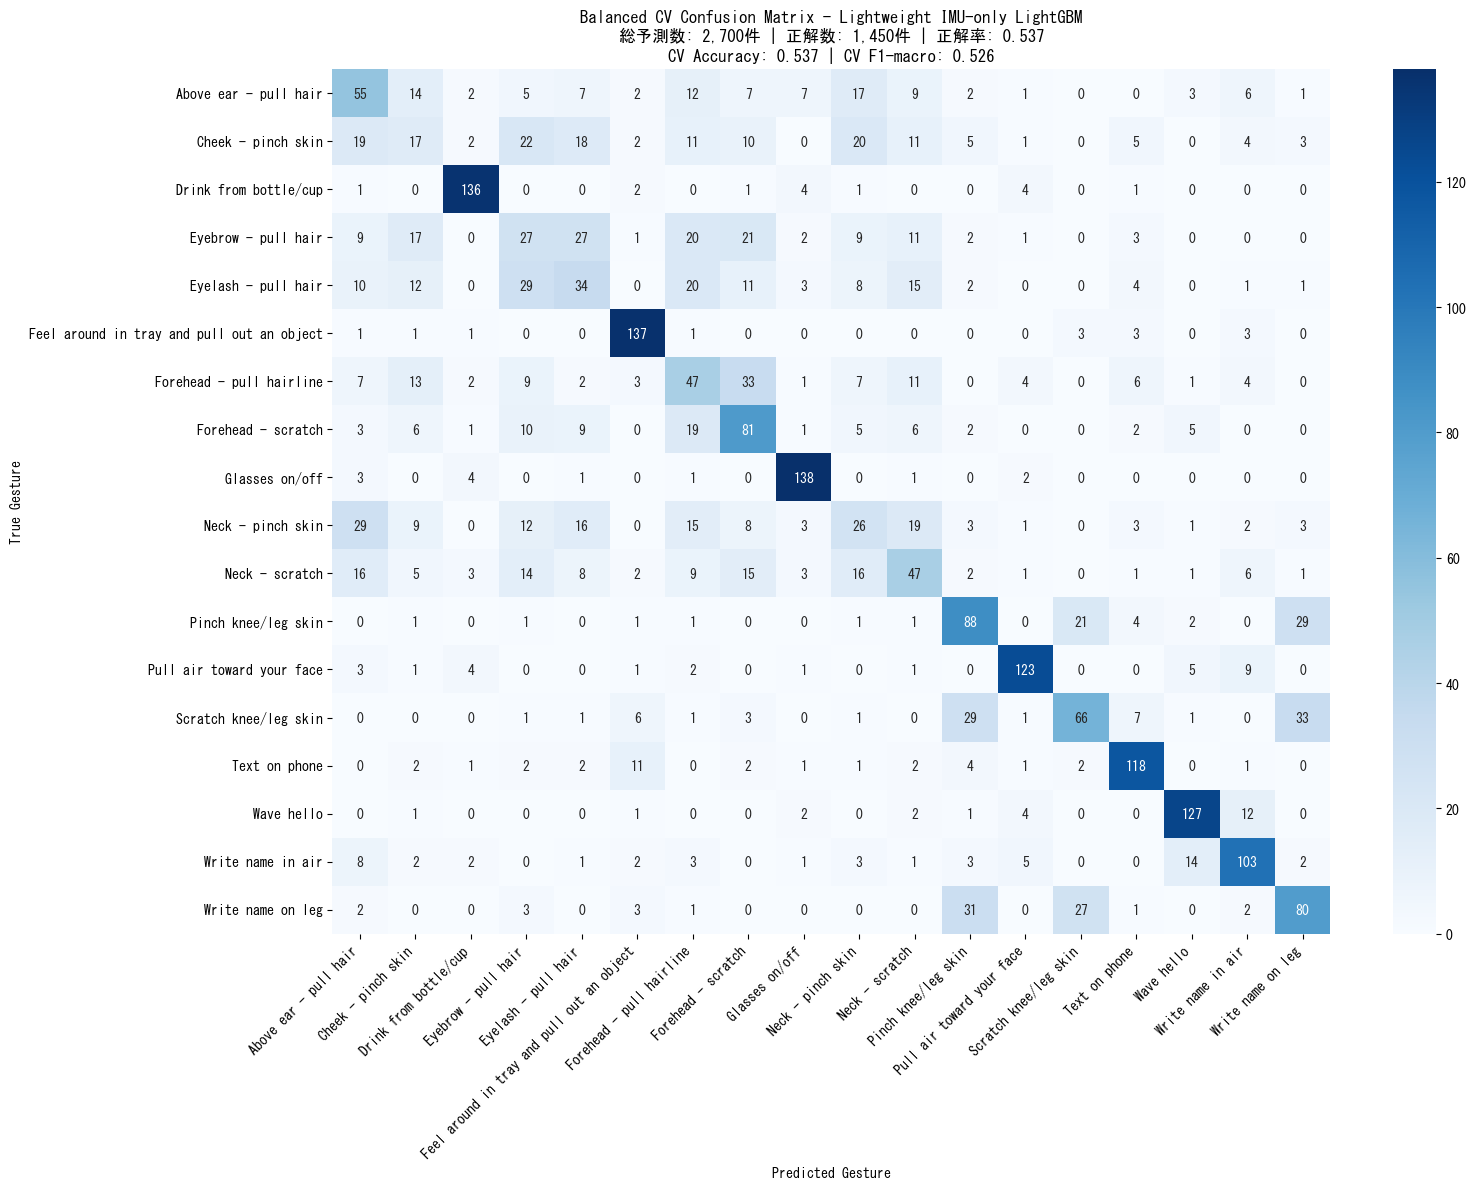


=== クラス別詳細統計 ===
Gesture                             真の件数     予測件数     正解件数     再現率      適合率     
-------------------------------------------------------------------------------------
Above ear - pull hair               150      166      55       0.367    0.331   
Cheek - pinch skin                  150      101      17       0.113    0.168   
Drink from bottle/cup               150      158      136      0.907    0.861   
Eyebrow - pull hair                 150      135      27       0.180    0.200   
Eyelash - pull hair                 150      126      34       0.227    0.270   
Feel around in tray and pull out an object 150      174      137      0.913    0.787   
Forehead - pull hairline            150      163      47       0.313    0.288   
Forehead - scratch                  150      192      81       0.540    0.422   
Glasses on/off                      150      167      138      0.920    0.826   
Neck - pinch skin                   150      115      26       0.173    0.226  

In [58]:
print("=== IMU-only モデル 学習・分析 ===")
(cm_imu_bal, y_true_imu_bal, y_pred_imu_bal, 
 trained_imu_model, imu_results) = balanced_cv_confusion_matrix_with_model(
    analysis_imu_model, X_imu_bal, y_imu_bal, groups_imu_bal, 
    "Lightweight IMU-only LightGBM", le_gesture.classes_, n_folds=CFG.n_folds
)

=== Full-sensor モデル 学習・分析 ===
=== Lightweight Full-sensor LightGBM バランスCV混同行列 (n_folds=5) ===
データサイズ: (2517, 872)
被験者グループ数: 79
Fold 1: Train=2016, Val=501
  Accuracy: 0.583, F1-macro: 0.571, Time: 30.0s
Fold 2: Train=2016, Val=501
  Accuracy: 0.573, F1-macro: 0.574, Time: 28.6s
Fold 3: Train=2015, Val=502
  Accuracy: 0.586, F1-macro: 0.577, Time: 28.4s
Fold 4: Train=2005, Val=512
  Accuracy: 0.539, F1-macro: 0.530, Time: 28.8s
Fold 5: Train=2016, Val=501
  Accuracy: 0.527, F1-macro: 0.518, Time: 29.3s

=== CV結果 ===
CV精度: 0.561
CV F1-macro: 0.554
CV実行時間: 145.1s


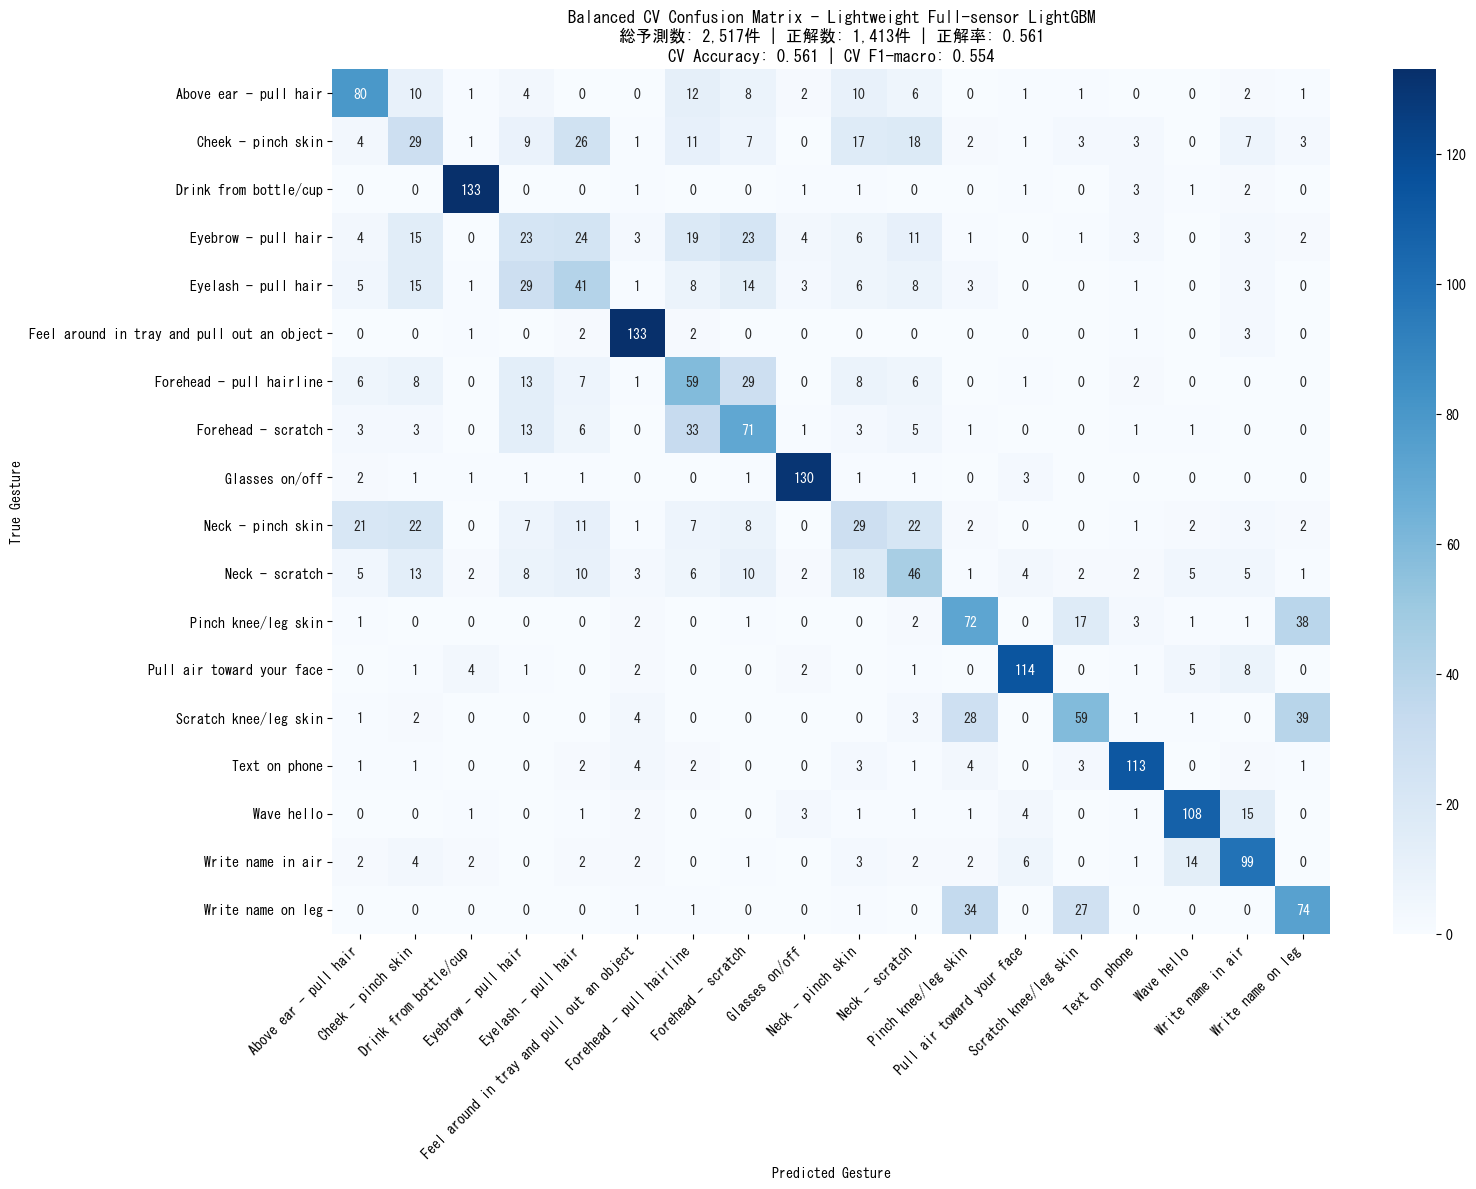


=== クラス別詳細統計 ===
Gesture                             真の件数     予測件数     正解件数     再現率      適合率     
-------------------------------------------------------------------------------------
Above ear - pull hair               138      135      80       0.580    0.593   
Cheek - pinch skin                  142      124      29       0.204    0.234   
Drink from bottle/cup               143      147      133      0.930    0.905   
Eyebrow - pull hair                 142      108      23       0.162    0.213   
Eyelash - pull hair                 138      133      41       0.297    0.308   
Feel around in tray and pull out an object 142      161      133      0.937    0.826   
Forehead - pull hairline            140      160      59       0.421    0.369   
Forehead - scratch                  141      173      71       0.504    0.410   
Glasses on/off                      142      148      130      0.915    0.878   
Neck - pinch skin                   138      107      29       0.210    0.271  

In [59]:
print("=== Full-sensor モデル 学習・分析 ===")
(cm_full_bal, y_true_full_bal, y_pred_full_bal, 
 trained_full_model, full_results) = balanced_cv_confusion_matrix_with_model(
    analysis_full_model, X_full_bal, y_full_bal, groups_full_bal, 
    "Lightweight Full-sensor LightGBM", le_gesture.classes_, n_folds=CFG.n_folds
)

## 1st model

In [29]:
# グループ分類モデル作成
group_imu_model = create_lightweight_model_for_analysis()
group_full_model = create_lightweight_model_for_analysis()

第一段階：3グループ分類モデル - IMU-only
=== 3-Group Classification (IMU-only) バランスCV混同行列 (n_folds=5) ===
データサイズ: (2700, 360)
被験者グループ数: 81
Fold 1: Train=2162, Val=538
  Accuracy: 0.907, F1-macro: 0.912, Time: 5.0s
Fold 2: Train=2164, Val=536
  Accuracy: 0.884, F1-macro: 0.874, Time: 3.5s
Fold 3: Train=2162, Val=538
  Accuracy: 0.961, F1-macro: 0.963, Time: 3.5s
Fold 4: Train=2162, Val=538
  Accuracy: 0.918, F1-macro: 0.918, Time: 3.4s
Fold 5: Train=2150, Val=550
  Accuracy: 0.909, F1-macro: 0.910, Time: 3.5s

=== CV結果 ===
CV精度: 0.916
CV F1-macro: 0.915
CV実行時間: 18.8s


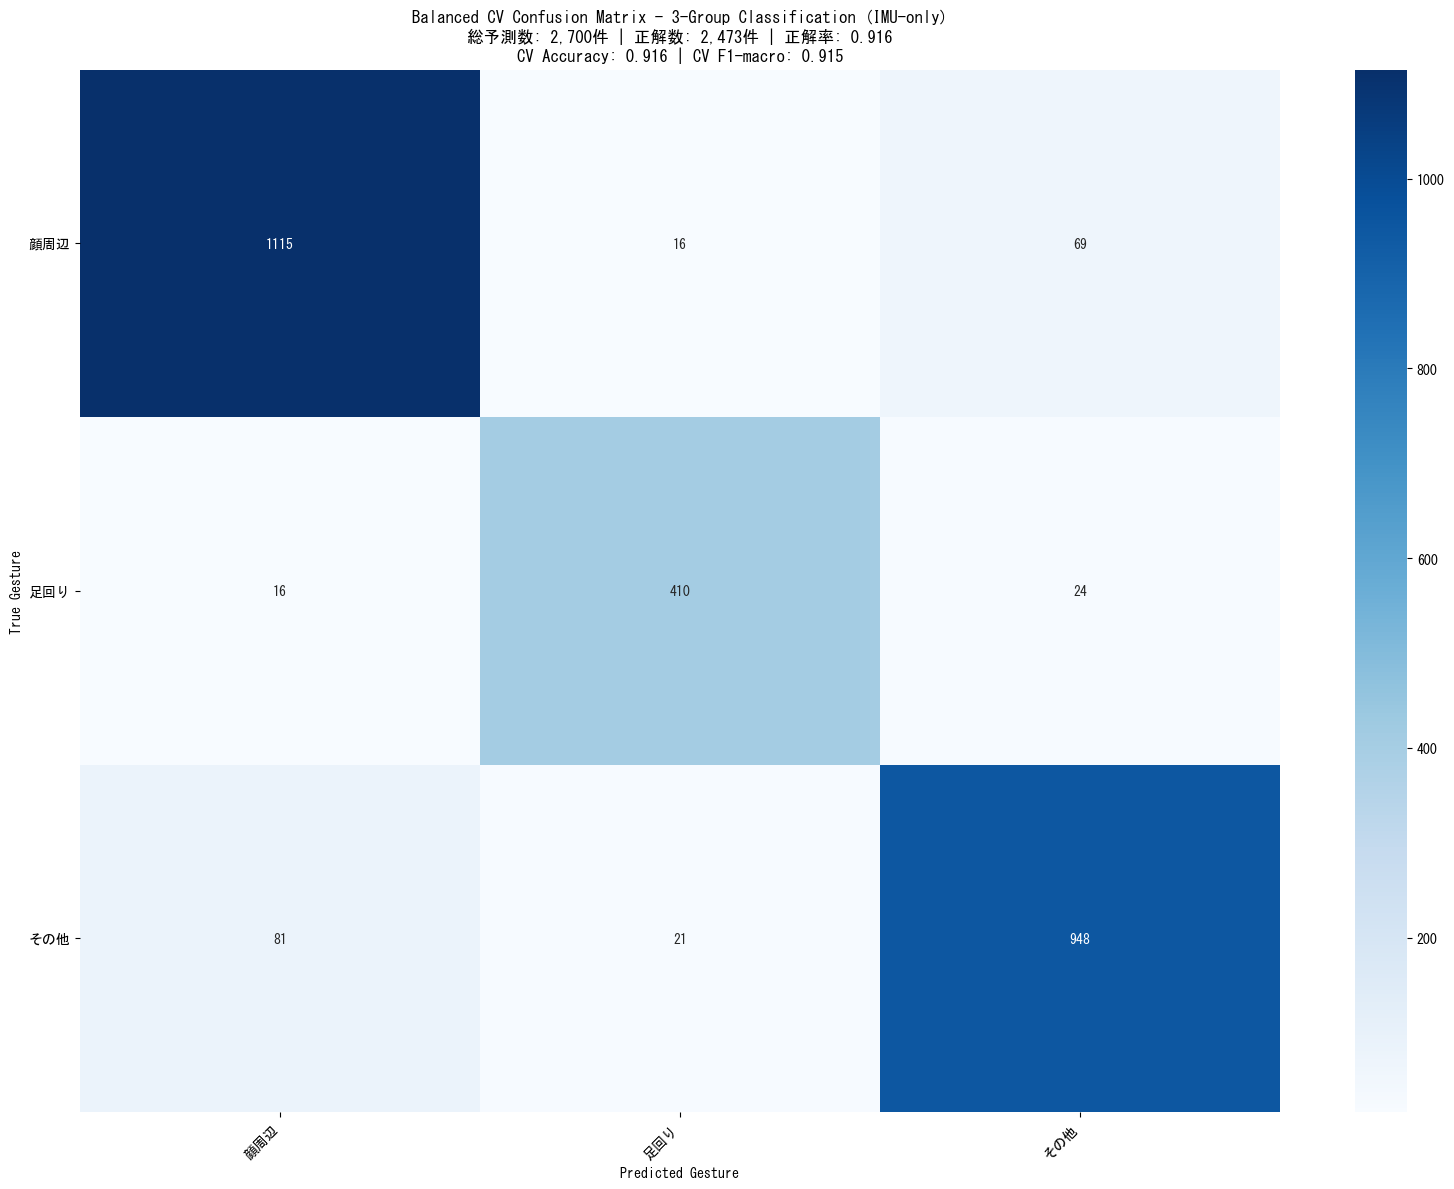


=== クラス別詳細統計 ===
Gesture                             真の件数     予測件数     正解件数     再現率      適合率     
-------------------------------------------------------------------------------------
顔周辺                                 1200     1212     1115     0.929    0.920   
足回り                                 450      447      410      0.911    0.917   
その他                                 1050     1041     948      0.903    0.911   

=== 全体サマリー ===
総予測数: 2,700件
総正解数: 2,473件
総誤答数: 227件
正解率: 0.916 (91.6%)

=== 最も混同しやすいジェスチャーペア（上位5位） ===
真のジェスチャー                            予測されたジェスチャー                         誤分類件数      誤分類率    
-----------------------------------------------------------------------------------------------
その他                                 顔周辺                                 81         0.077   
顔周辺                                 その他                                 69         0.058   
足回り                                 その他                                 24         0.053   
その他 

In [30]:
print("=" * 80)
print("第一段階：3グループ分類モデル - IMU-only")
print("=" * 80)

(cm_group_imu, y_true_group_imu, y_pred_group_imu, 
 trained_group_imu_model, group_imu_results) = balanced_cv_confusion_matrix_with_model(
    group_imu_model, X_imu_bal, y_group_imu, groups_imu_bal,
    "3-Group Classification (IMU-only)", group_names, n_folds=CFG.n_folds
)

第一段階：3グループ分類モデル - Full-sensor
=== 3-Group Classification (Full-sensor) バランスCV混同行列 (n_folds=5) ===
データサイズ: (2517, 872)
被験者グループ数: 79
Fold 1: Train=2016, Val=501
  Accuracy: 0.954, F1-macro: 0.961, Time: 6.7s
Fold 2: Train=2016, Val=501
  Accuracy: 0.948, F1-macro: 0.948, Time: 6.7s
Fold 3: Train=2015, Val=502
  Accuracy: 0.960, F1-macro: 0.963, Time: 6.6s
Fold 4: Train=2005, Val=512
  Accuracy: 0.926, F1-macro: 0.920, Time: 6.6s
Fold 5: Train=2016, Val=501
  Accuracy: 0.952, F1-macro: 0.951, Time: 6.6s

=== CV結果 ===
CV精度: 0.948
CV F1-macro: 0.948
CV実行時間: 33.2s


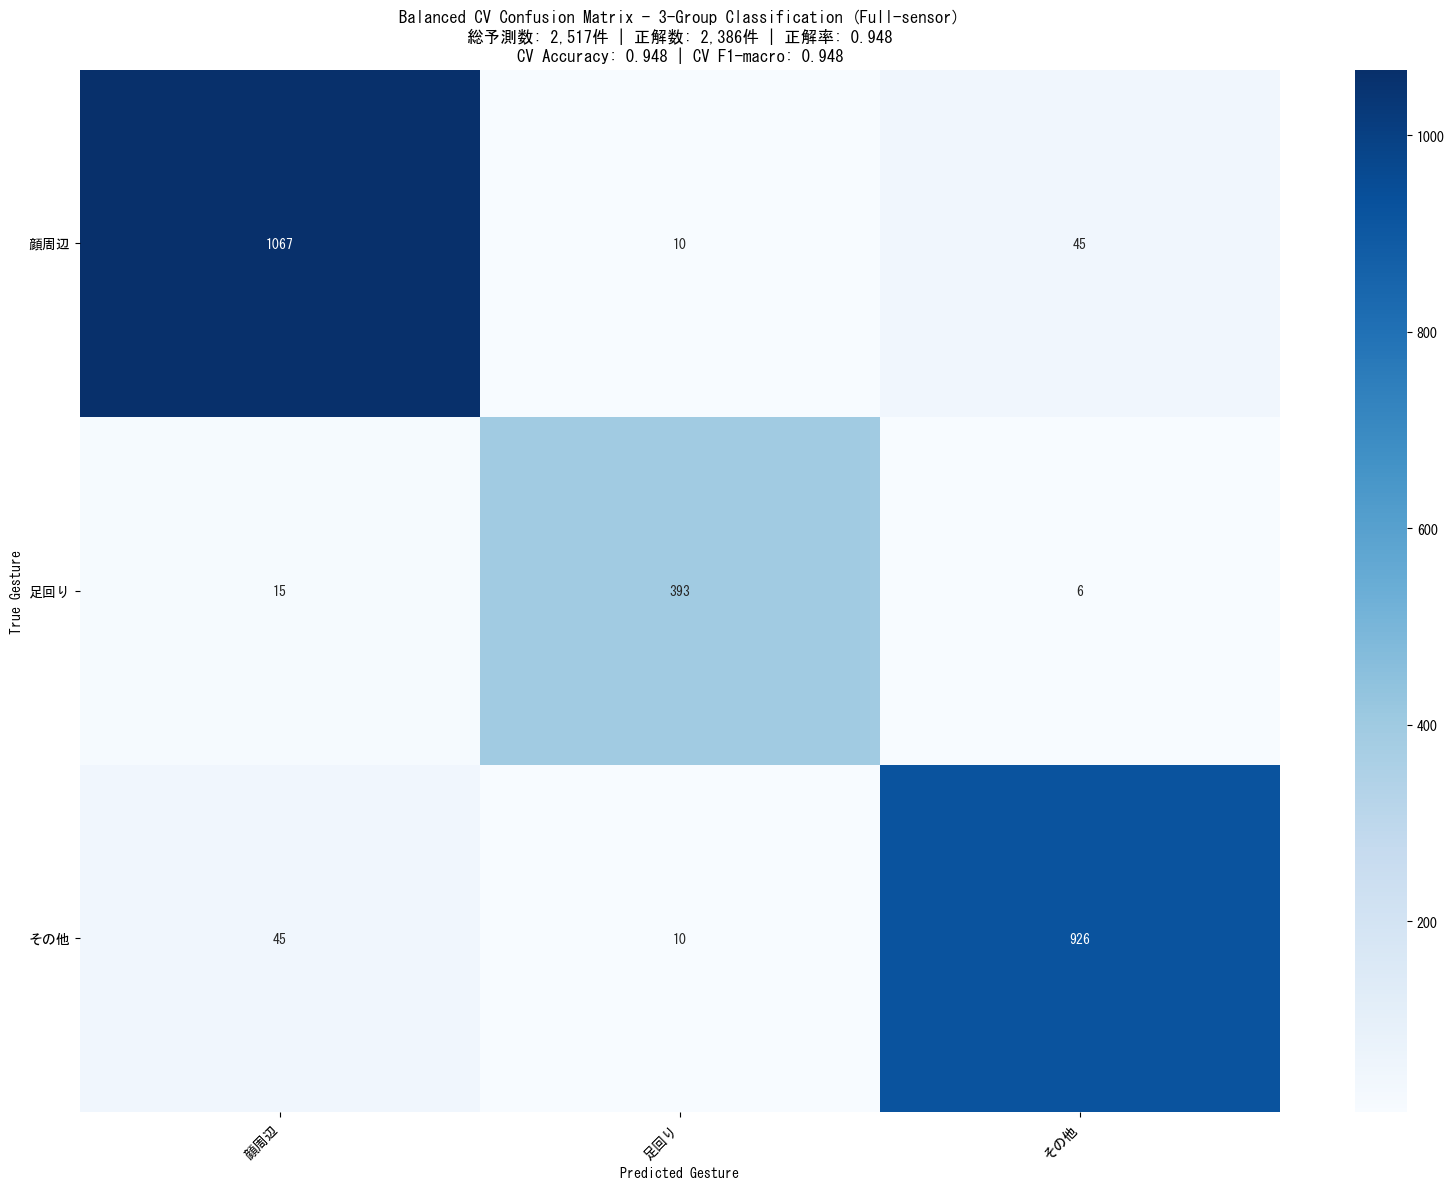


=== クラス別詳細統計 ===
Gesture                             真の件数     予測件数     正解件数     再現率      適合率     
-------------------------------------------------------------------------------------
顔周辺                                 1122     1127     1067     0.951    0.947   
足回り                                 414      413      393      0.949    0.952   
その他                                 981      977      926      0.944    0.948   

=== 全体サマリー ===
総予測数: 2,517件
総正解数: 2,386件
総誤答数: 131件
正解率: 0.948 (94.8%)

=== 最も混同しやすいジェスチャーペア（上位5位） ===
真のジェスチャー                            予測されたジェスチャー                         誤分類件数      誤分類率    
-----------------------------------------------------------------------------------------------
顔周辺                                 その他                                 45         0.040   
その他                                 顔周辺                                 45         0.046   
足回り                                 顔周辺                                 15         0.036   
顔周辺 

In [31]:
print("=" * 80)  
print("第一段階：3グループ分類モデル - Full-sensor")
print("=" * 80)

(cm_group_full, y_true_group_full, y_pred_group_full,
 trained_group_full_model, group_full_results) = balanced_cv_confusion_matrix_with_model(
    group_full_model, X_full_bal, y_group_full, groups_full_bal,
    "3-Group Classification (Full-sensor)", group_names, n_folds=CFG.n_folds
)

## 2nd model

In [32]:
def create_group_specific_datasets(X, y_gesture, y_group, groups, gesture_to_group, group_id, group_name):
    """
    指定グループのデータセットを作成し、ラベルを再エンコーディング
    """
    print(f"=== {group_name}グループ データセット作成 ===")
    
    # 該当グループのインデックス取得
    group_mask = y_group == group_id
    
    # データ抽出
    X_group = X[group_mask].copy()
    y_gesture_group = y_gesture[group_mask].copy()
    groups_group = [groups[i] for i in range(len(groups)) if group_mask.iloc[i]]
    
    # グループ内のジェスチャー特定
    group_gestures = [gesture for gesture, gid in gesture_to_group.items() if gid == group_id]
    print(f"対象ジェスチャー ({len(group_gestures)}個): {group_gestures}")
    
    # ラベル再エンコーディング（0から連番に）
    gesture_mapping = {le_gesture.transform([gesture])[0]: i for i, gesture in enumerate(group_gestures)}
    y_group_encoded = y_gesture_group.map(gesture_mapping)
    
    print(f"データサイズ: {X_group.shape}")
    print(f"サンプル数: {len(X_group)}")
    print(f"被験者数: {len(set(groups_group))}")
    
    # ラベル分布確認
    label_counts = y_group_encoded.value_counts().sort_index()
    print("ラベル分布:")
    for i, count in label_counts.items():
        gesture_name = group_gestures[i]
        print(f"  {i}: {gesture_name} -> {count}サンプル ({count/len(y_group_encoded)*100:.1f}%)")
    
    return X_group, y_group_encoded, groups_group, group_gestures

# 各グループのデータセット作成
print("IMU-onlyデータでのグループ別分割:")

# 顔周辺グループ (最重要)
X_face_imu, y_face_imu, groups_face_imu, face_gestures = create_group_specific_datasets(
    X_imu_bal, y_imu_bal, y_group_imu, groups_imu_bal, gesture_to_group, 0, "顔周辺"
)

# 足回りグループ (検証用)  
X_leg_imu, y_leg_imu, groups_leg_imu, leg_gestures = create_group_specific_datasets(
    X_imu_bal, y_imu_bal, y_group_imu, groups_imu_bal, gesture_to_group, 1, "足回り"
)

# その他グループ
X_other_imu, y_other_imu, groups_other_imu, other_gestures = create_group_specific_datasets(
    X_imu_bal, y_imu_bal, y_group_imu, groups_imu_bal, gesture_to_group, 2, "その他"
)

print("\nFull-sensorデータでのグループ別分割:")

# Full-sensor版も同様に作成
X_face_full, y_face_full, groups_face_full, _ = create_group_specific_datasets(
    X_full_bal, y_full_bal, y_group_full, groups_full_bal, gesture_to_group, 0, "顔周辺"
)

X_leg_full, y_leg_full, groups_leg_full, _ = create_group_specific_datasets(
    X_full_bal, y_full_bal, y_group_full, groups_full_bal, gesture_to_group, 1, "足回り"
)

X_other_full, y_other_full, groups_other_full, _ = create_group_specific_datasets(
    X_full_bal, y_full_bal, y_group_full, groups_full_bal, gesture_to_group, 2, "その他"
)

IMU-onlyデータでのグループ別分割:
=== 顔周辺グループ データセット作成 ===
対象ジェスチャー (8個): ['Above ear - pull hair', 'Cheek - pinch skin', 'Eyebrow - pull hair', 'Eyelash - pull hair', 'Forehead - pull hairline', 'Forehead - scratch', 'Neck - pinch skin', 'Neck - scratch']
データサイズ: (1200, 360)
サンプル数: 1200
被験者数: 81
ラベル分布:
  0: Above ear - pull hair -> 150サンプル (12.5%)
  1: Cheek - pinch skin -> 150サンプル (12.5%)
  2: Eyebrow - pull hair -> 150サンプル (12.5%)
  3: Eyelash - pull hair -> 150サンプル (12.5%)
  4: Forehead - pull hairline -> 150サンプル (12.5%)
  5: Forehead - scratch -> 150サンプル (12.5%)
  6: Neck - pinch skin -> 150サンプル (12.5%)
  7: Neck - scratch -> 150サンプル (12.5%)
=== 足回りグループ データセット作成 ===
対象ジェスチャー (3個): ['Pinch knee/leg skin', 'Scratch knee/leg skin', 'Write name on leg']
データサイズ: (450, 360)
サンプル数: 450
被験者数: 81
ラベル分布:
  0: Pinch knee/leg skin -> 150サンプル (33.3%)
  1: Scratch knee/leg skin -> 150サンプル (33.3%)
  2: Write name on leg -> 150サンプル (33.3%)
=== その他グループ データセット作成 ===
対象ジェスチャー (7個): ['Drink from bottle/cup', 'Fe

In [33]:
def classify_sensor_type(feature_name):
    """
    特徴量名からセンサータイプを判定
    """
    if any(sensor in feature_name for sensor in ['acc_', 'rot_', 'linear_acc_', 'angular_vel_']):
        return 'IMU'
    elif 'thm_' in feature_name:
        return 'Thermal'
    elif 'tof_' in feature_name:
        return 'ToF'
    elif feature_name in ['age', 'sex', 'height_cm', 'handedness']:
        return 'Demographics'
    else:
        return 'Other'

In [34]:
def analyze_group_specific_features(X, y, groups, group_name, n_top_features=50):
    """
    グループ特化の特徴量重要度分析
    """
    print(f"\n=== {group_name}グループ 特徴量重要度分析 ===")
    
    # 軽量モデルで特徴量重要度を取得
    model = LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=CFG.seed,
        verbose=-1
    )
    
    # 全データで学習
    model.fit(X, y)
    
    # 特徴量重要度取得
    importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(f"全特徴量数: {len(importance_df)}")
    print(f"Top {n_top_features} 特徴量:")
    print(importance_df.head(n_top_features))
    
    # センサータイプ別分析
    importance_df['sensor_type'] = importance_df['feature'].apply(classify_sensor_type)
    sensor_summary = importance_df.groupby('sensor_type')['importance'].agg(['count', 'sum', 'mean']).round(4)
    print(f"\nセンサータイプ別重要度:")
    print(sensor_summary)
    
    return importance_df

In [50]:
face_features_imu = analyze_group_specific_features(X_face_imu, y_face_imu, groups_face_imu, "顔周辺(IMU)")
leg_features_imu = analyze_group_specific_features(X_leg_imu, y_leg_imu, groups_leg_imu, "足回り(IMU)")
other_features_imu = analyze_group_specific_features(X_other_imu, y_other_imu, groups_other_imu, "その他(IMU)")


=== 顔周辺(IMU)グループ 特徴量重要度分析 ===
全特徴量数: 360
Top 50 特徴量:
                                      feature  importance
340  linear_acc_jerk_y_linear_acc_jerk_z_corr         257
344                          rot_x_rot_y_corr         223
351               linear_acc_mag_rot_mag_corr         198
282                    angular_vel_y_fft_high         181
338  linear_acc_jerk_x_linear_acc_jerk_y_corr         178
302                   angular_vel_mag_fft_max         174
86                  linear_acc_jerk_z_fft_max         174
275                         angular_vel_y_max         159
46                         linear_acc_mag_min         157
274                         angular_vel_y_min         157
341  global_acc_jerk_x_global_acc_jerk_y_corr         150
339  linear_acc_jerk_x_linear_acc_jerk_z_corr         149
354           raw_acc_mag_linear_acc_mag_corr         149
334            linear_acc_y_linear_acc_z_corr         147
349          angular_vel_y_angular_vel_z_corr         146
225               

In [51]:
face_features_full = analyze_group_specific_features(X_face_full, y_face_full, groups_face_full, "顔周辺(Full)")
leg_features_full = analyze_group_specific_features(X_leg_full, y_leg_full, groups_leg_full, "足回り(Full)")
other_features_full = analyze_group_specific_features(X_other_full, y_other_full, groups_other_full, "その他(Full)")


=== 顔周辺(Full)グループ 特徴量重要度分析 ===
全特徴量数: 872
Top 50 特徴量:
                                      feature  importance
361                                 thm_2_max         395
357                    thm_std_across_sensors         350
359                                 thm_1_max         237
344                          rot_x_rot_y_corr         179
360                                thm_2_mean         175
340  linear_acc_jerk_y_linear_acc_jerk_z_corr         152
302                   angular_vel_mag_fft_max         134
334            linear_acc_y_linear_acc_z_corr         118
86                  linear_acc_jerk_z_fft_max         113
349          angular_vel_y_angular_vel_z_corr         110
364                                thm_4_mean         108
351               linear_acc_mag_rot_mag_corr          99
363                                 thm_3_max          99
282                    angular_vel_y_fft_high          98
225                                 rot_z_std          98
280              

In [52]:
def optimize_features_for_group(X, y, importance_df, group_name, reduction_ratio=0.9):
    """
    グループ特化の特徴量選択
    """
    print(f"\n=== {group_name} 特徴量最適化 ===")
    
    # 累積重要度による特徴量選択
    cumulative_importance = importance_df['importance'].cumsum() / importance_df['importance'].sum()
    selected_features = importance_df[cumulative_importance <= reduction_ratio]['feature'].tolist()
    
    # 最適化後のデータセット
    X_optimized = X[selected_features].copy()
    
    print(f"元の特徴量数: {X.shape[1]}")
    print(f"最適化後特徴量数: {X_optimized.shape[1]}")
    print(f"削減率: {(1 - X_optimized.shape[1]/X.shape[1])*100:.1f}%")
    
    # センサータイプ別の選択状況
    selected_importance = importance_df[importance_df['feature'].isin(selected_features)]
    sensor_dist = selected_importance['sensor_type'].value_counts()
    print(f"選択された特徴量のセンサータイプ分布:")
    print(sensor_dist)
    
    return X_optimized, selected_features

In [53]:
# 各グループの特徴量最適化
print("\n顔周辺グループの特徴量最適化:")
X_face_imu_opt, face_features_selected_imu = optimize_features_for_group(
    X_face_imu, y_face_imu, face_features_imu, "顔周辺(IMU)", reduction_ratio=0.9
)

X_face_full_opt, face_features_selected_full = optimize_features_for_group(
    X_face_full, y_face_full, face_features_full, "顔周辺(Full)", reduction_ratio=0.9
)

print("足回りグループの特徴量最適化:")
X_leg_imu_opt, leg_features_selected_imu = optimize_features_for_group(
    X_leg_imu, y_leg_imu, leg_features_imu, "足回り(IMU)", reduction_ratio=0.9
)

X_leg_full_opt, leg_features_selected_full = optimize_features_for_group(
    X_leg_full, y_leg_full, leg_features_full, "足回り(Full)", reduction_ratio=0.9
)

print("\nその他グループの特徴量最適化:")
X_other_imu_opt, other_features_selected_imu = optimize_features_for_group(
    X_other_imu, y_other_imu, other_features_imu, "その他(IMU)", reduction_ratio=0.9
)

X_other_full_opt, other_features_selected_full = optimize_features_for_group(
    X_other_full, y_other_full, other_features_full, "その他(Full)", reduction_ratio=0.9
)


顔周辺グループの特徴量最適化:

=== 顔周辺(IMU) 特徴量最適化 ===
元の特徴量数: 360
最適化後特徴量数: 251
削減率: 30.3%
選択された特徴量のセンサータイプ分布:
sensor_type
IMU             241
Other             8
Demographics      2
Name: count, dtype: int64

=== 顔周辺(Full) 特徴量最適化 ===
元の特徴量数: 872
最適化後特徴量数: 616
削減率: 29.4%
選択された特徴量のセンサータイプ分布:
sensor_type
ToF             308
IMU             286
Thermal          12
Other             8
Demographics      2
Name: count, dtype: int64
足回りグループの特徴量最適化:

=== 足回り(IMU) 特徴量最適化 ===
元の特徴量数: 360
最適化後特徴量数: 220
削減率: 38.9%
選択された特徴量のセンサータイプ分布:
sensor_type
IMU             212
Other             7
Demographics      1
Name: count, dtype: int64

=== 足回り(Full) 特徴量最適化 ===
元の特徴量数: 872
最適化後特徴量数: 512
削減率: 41.3%
選択された特徴量のセンサータイプ分布:
sensor_type
ToF        311
IMU        190
Thermal      7
Other        4
Name: count, dtype: int64

その他グループの特徴量最適化:

=== その他(IMU) 特徴量最適化 ===
元の特徴量数: 360
最適化後特徴量数: 227
削減率: 36.9%
選択された特徴量のセンサータイプ分布:
sensor_type
IMU      221
Other      6
Name: count, dtype: int64

=== その他(Full) 特徴量最適化 ===
元の特徴量数: 872
最適化後

In [44]:
def create_optimized_group_model(n_classes, model_name="Optimized-Group"):
    """
    グループ特化・最適化モデル作成
    """
    return LGBMClassifier(
        objective='multiclass',
        num_class=n_classes,
        n_estimators=250,  # 特徴量削減した分、少し多めに
        learning_rate=0.08,
        feature_fraction=0.95,  # 最適化済みなので高めに設定
        bagging_fraction=0.85,
        num_leaves=31,
        max_depth=8,
        min_child_samples=20,
        random_state=CFG.seed,
        verbose=-1,
        importance_type='gain'
    )

In [45]:
def compare_model_performance(original_results, optimized_results, group_name):
    """
    元モデルと最適化モデルの性能比較
    """
    print(f"\n=== {group_name} 性能比較 ===")
    print(f"{'指標':<20} {'元モデル':<12} {'最適化後':<12} {'差分':<10} {'改善率':<10}")
    print("-" * 65)
    
    orig_acc = original_results['cv_accuracy']
    opt_acc = optimized_results['cv_accuracy']
    acc_diff = opt_acc - orig_acc
    acc_improvement = (acc_diff / orig_acc * 100) if orig_acc > 0 else 0
    
    orig_f1 = original_results['cv_f1_macro']
    opt_f1 = optimized_results['cv_f1_macro']
    f1_diff = opt_f1 - orig_f1
    f1_improvement = (f1_diff / orig_f1 * 100) if orig_f1 > 0 else 0
    
    print(f"{'CV Accuracy':<20} {orig_acc:<12.3f} {opt_acc:<12.3f} {acc_diff:<10.3f} {acc_improvement:<10.1f}%")
    print(f"{'CV F1-macro':<20} {orig_f1:<12.3f} {opt_f1:<12.3f} {f1_diff:<10.3f} {f1_improvement:<10.1f}%")
    
    # 学習時間比較
    orig_time = original_results['cv_time']
    opt_time = optimized_results['cv_time']
    time_diff = opt_time - orig_time
    time_improvement = (time_diff / orig_time * 100) if orig_time > 0 else 0
    
    print(f"{'学習時間(秒)':<20} {orig_time:<12.1f} {opt_time:<12.1f} {time_diff:<10.1f} {time_improvement:<10.1f}%")


### Leg

足回り最適化モデル (IMU-only) 学習中...
=== 足回り最適化モデル (IMU-only) バランスCV混同行列 (n_folds=5) ===
データサイズ: (450, 220)
被験者グループ数: 81
Fold 1: Train=360, Val=90
  Accuracy: 0.544, F1-macro: 0.543, Time: 0.3s
Fold 2: Train=360, Val=90
  Accuracy: 0.600, F1-macro: 0.588, Time: 0.4s
Fold 3: Train=358, Val=92
  Accuracy: 0.620, F1-macro: 0.620, Time: 0.4s
Fold 4: Train=361, Val=89
  Accuracy: 0.596, F1-macro: 0.592, Time: 0.4s
Fold 5: Train=361, Val=89
  Accuracy: 0.607, F1-macro: 0.607, Time: 0.4s

=== CV結果 ===
CV精度: 0.593
CV F1-macro: 0.591
CV実行時間: 1.8s


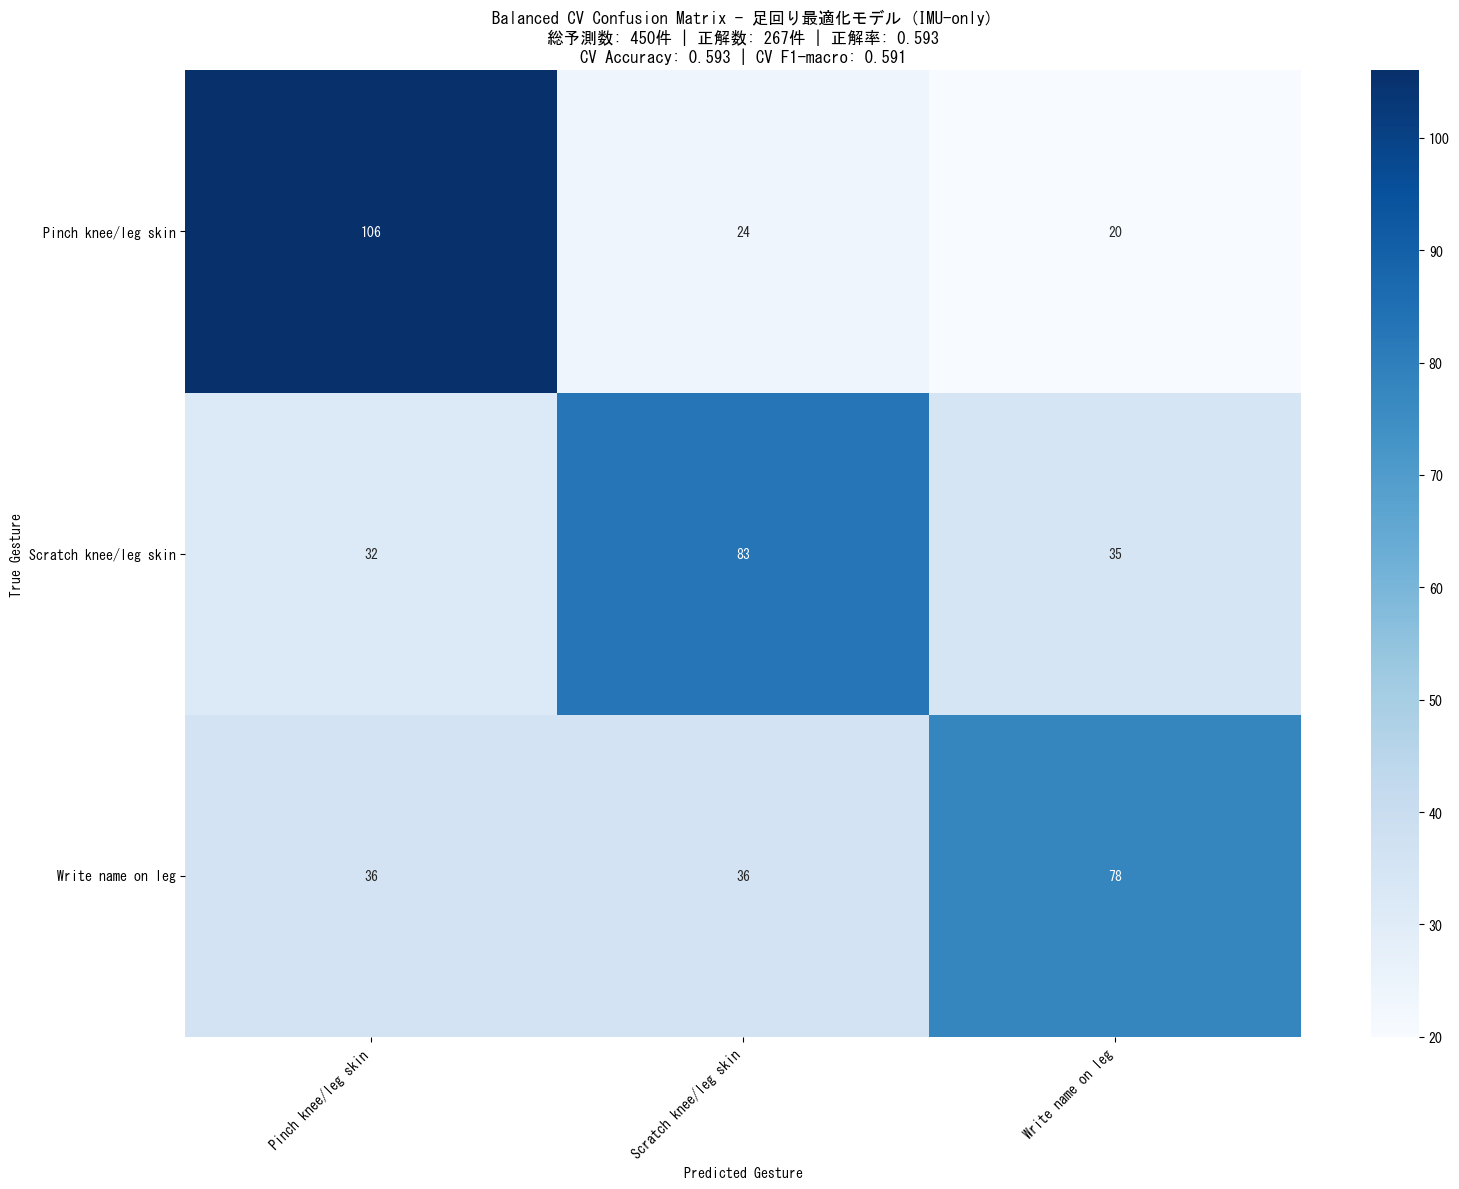


=== クラス別詳細統計 ===
Gesture                             真の件数     予測件数     正解件数     再現率      適合率     
-------------------------------------------------------------------------------------
Pinch knee/leg skin                 150      174      106      0.707    0.609   
Scratch knee/leg skin               150      143      83       0.553    0.580   
Write name on leg                   150      133      78       0.520    0.586   

=== 全体サマリー ===
総予測数: 450件
総正解数: 267件
総誤答数: 183件
正解率: 0.593 (59.3%)

=== 最も混同しやすいジェスチャーペア（上位5位） ===
真のジェスチャー                            予測されたジェスチャー                         誤分類件数      誤分類率    
-----------------------------------------------------------------------------------------------
Write name on leg                   Pinch knee/leg skin                 36         0.240   
Write name on leg                   Scratch knee/leg skin               36         0.240   
Scratch knee/leg skin               Write name on leg                   35         0.233   
Scratch 

In [46]:
# 足回りモデル（3分類）- IMU-only
leg_model_opt_imu = create_optimized_group_model(3, "Leg-Optimized-IMU")

print("足回り最適化モデル (IMU-only) 学習中...")
(cm_leg_opt_imu, y_true_leg_opt_imu, y_pred_leg_opt_imu, 
 trained_leg_opt_imu, leg_opt_imu_results) = balanced_cv_confusion_matrix_with_model(
    leg_model_opt_imu, X_leg_imu_opt, y_leg_imu, groups_leg_imu,
    "足回り最適化モデル (IMU-only)", leg_gestures, n_folds=CFG.n_folds
)

足回り最適化モデル (Full-sensor) 学習中...
=== 足回り最適化モデル (Full-sensor) バランスCV混同行列 (n_folds=5) ===
データサイズ: (414, 512)
被験者グループ数: 74
Fold 1: Train=330, Val=84
  Accuracy: 0.500, F1-macro: 0.497, Time: 0.6s
Fold 2: Train=334, Val=80
  Accuracy: 0.487, F1-macro: 0.478, Time: 0.7s
Fold 3: Train=330, Val=84
  Accuracy: 0.619, F1-macro: 0.617, Time: 0.7s
Fold 4: Train=331, Val=83
  Accuracy: 0.675, F1-macro: 0.671, Time: 0.7s
Fold 5: Train=331, Val=83
  Accuracy: 0.590, F1-macro: 0.586, Time: 0.7s

=== CV結果 ===
CV精度: 0.575
CV F1-macro: 0.573
CV実行時間: 3.3s


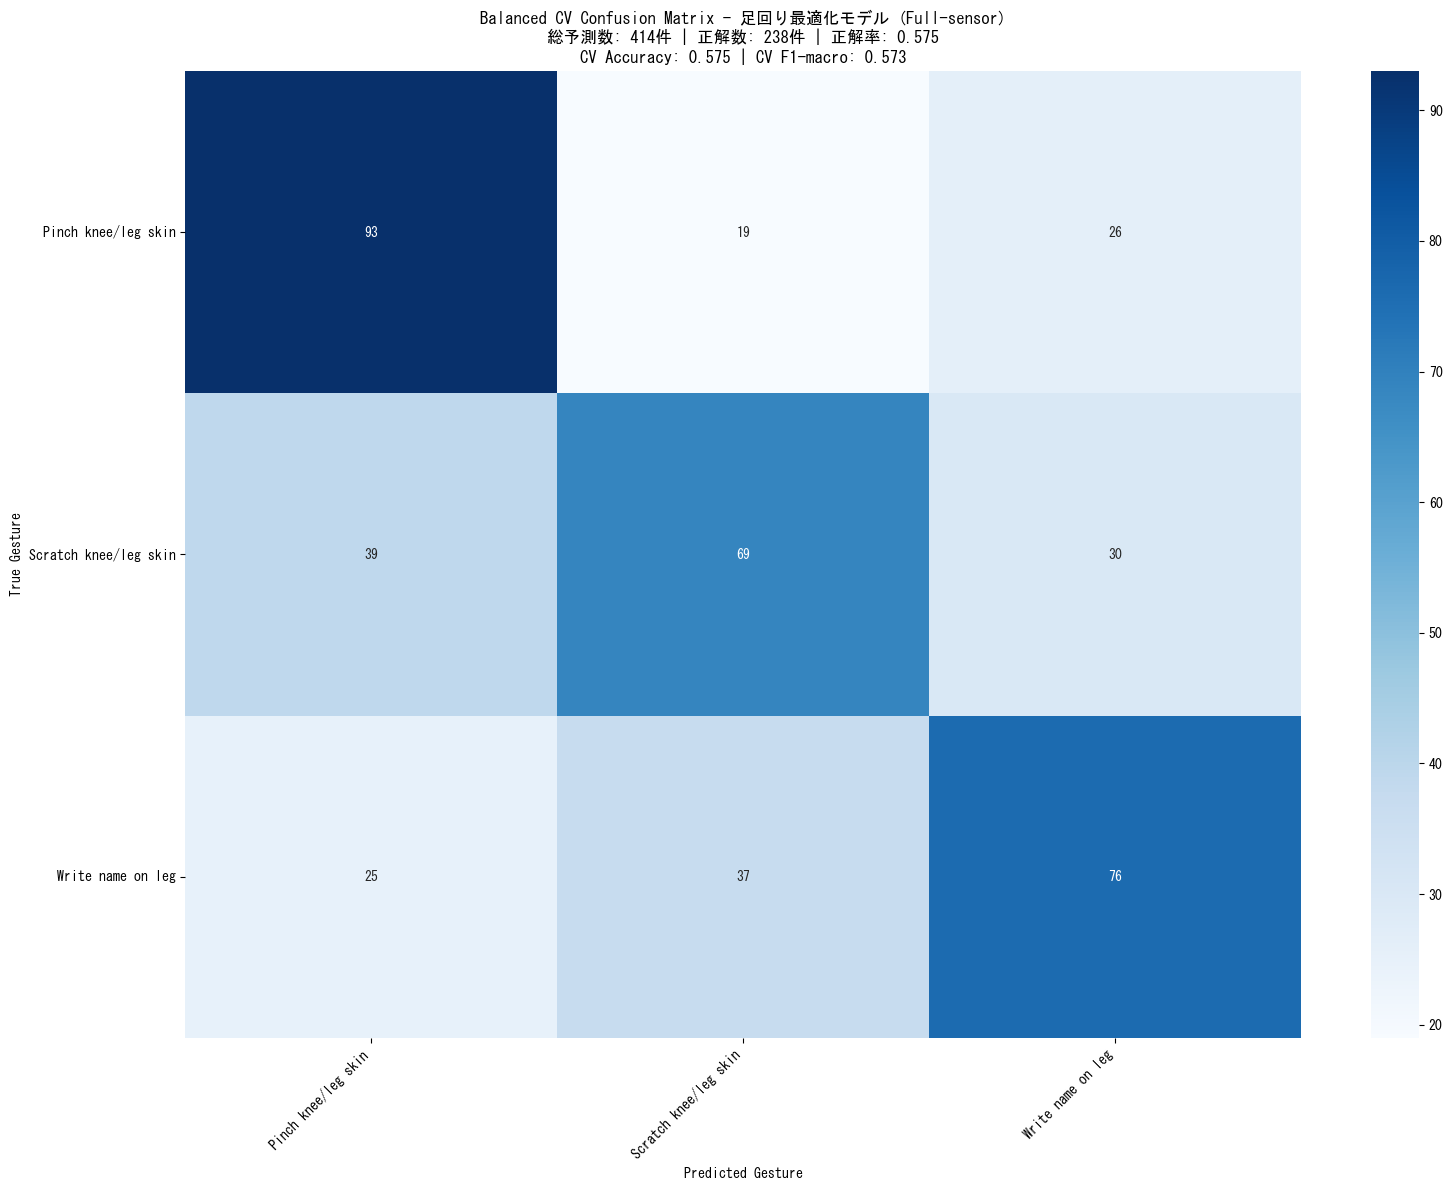


=== クラス別詳細統計 ===
Gesture                             真の件数     予測件数     正解件数     再現率      適合率     
-------------------------------------------------------------------------------------
Pinch knee/leg skin                 138      157      93       0.674    0.592   
Scratch knee/leg skin               138      125      69       0.500    0.552   
Write name on leg                   138      132      76       0.551    0.576   

=== 全体サマリー ===
総予測数: 414件
総正解数: 238件
総誤答数: 176件
正解率: 0.575 (57.5%)

=== 最も混同しやすいジェスチャーペア（上位5位） ===
真のジェスチャー                            予測されたジェスチャー                         誤分類件数      誤分類率    
-----------------------------------------------------------------------------------------------
Scratch knee/leg skin               Pinch knee/leg skin                 39         0.283   
Write name on leg                   Scratch knee/leg skin               37         0.268   
Scratch knee/leg skin               Write name on leg                   30         0.217   
Pinch kn

In [47]:
# 足回りモデル（3分類）- Full-sensor
leg_model_opt_full = create_optimized_group_model(3, "Leg-Optimized-Full")

print("足回り最適化モデル (Full-sensor) 学習中...")
(cm_leg_opt_full, y_true_leg_opt_full, y_pred_leg_opt_full,
 trained_leg_opt_full, leg_opt_full_results) = balanced_cv_confusion_matrix_with_model(
    leg_model_opt_full, X_leg_full_opt, y_leg_full, groups_leg_full,
    "足回り最適化モデル (Full-sensor)", leg_gestures, n_folds=CFG.n_folds
)

### Face

顔周辺最適化モデル (IMU-only) 学習中...
=== 顔周辺最適化モデル (IMU-only) バランスCV混同行列 (n_folds=5) ===
データサイズ: (1200, 251)
被験者グループ数: 81
Fold 1: Train=955, Val=245
  Accuracy: 0.347, F1-macro: 0.344, Time: 2.3s
Fold 2: Train=962, Val=238
  Accuracy: 0.307, F1-macro: 0.300, Time: 2.3s
Fold 3: Train=961, Val=239
  Accuracy: 0.322, F1-macro: 0.311, Time: 2.4s
Fold 4: Train=961, Val=239
  Accuracy: 0.331, F1-macro: 0.314, Time: 2.4s
Fold 5: Train=961, Val=239
  Accuracy: 0.285, F1-macro: 0.276, Time: 2.4s

=== CV結果 ===
CV精度: 0.318
CV F1-macro: 0.311
CV実行時間: 11.8s


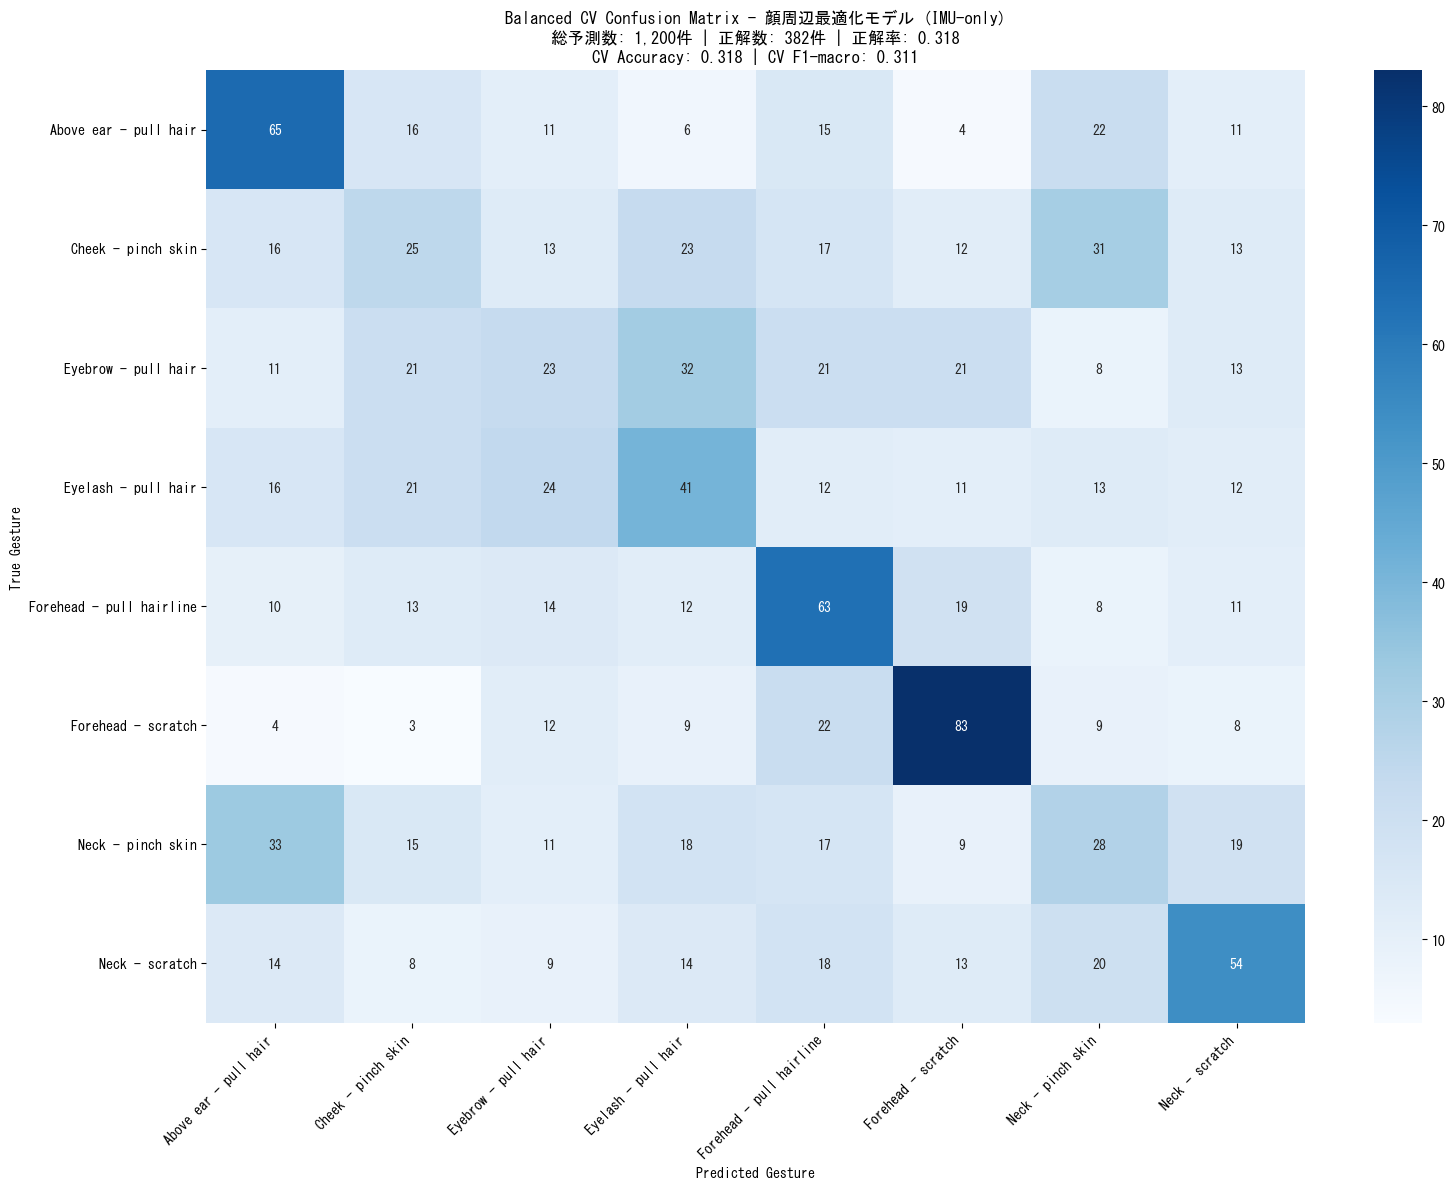


=== クラス別詳細統計 ===
Gesture                             真の件数     予測件数     正解件数     再現率      適合率     
-------------------------------------------------------------------------------------
Above ear - pull hair               150      169      65       0.433    0.385   
Cheek - pinch skin                  150      122      25       0.167    0.205   
Eyebrow - pull hair                 150      117      23       0.153    0.197   
Eyelash - pull hair                 150      155      41       0.273    0.265   
Forehead - pull hairline            150      185      63       0.420    0.341   
Forehead - scratch                  150      172      83       0.553    0.483   
Neck - pinch skin                   150      139      28       0.187    0.201   
Neck - scratch                      150      141      54       0.360    0.383   

=== 全体サマリー ===
総予測数: 1,200件
総正解数: 382件
総誤答数: 818件
正解率: 0.318 (31.8%)

=== 最も混同しやすいジェスチャーペア（上位5位） ===
真のジェスチャー                            予測されたジェスチャー                  

In [48]:
# 顔周辺モデル（8分類）- IMU-only
face_model_opt_imu = create_optimized_group_model(8, "Face-Optimized-IMU")

print("顔周辺最適化モデル (IMU-only) 学習中...")
(cm_face_opt_imu, y_true_face_opt_imu, y_pred_face_opt_imu,
 trained_face_opt_imu, face_opt_imu_results) = balanced_cv_confusion_matrix_with_model(
    face_model_opt_imu, X_face_imu_opt, y_face_imu, groups_face_imu,
    "顔周辺最適化モデル (IMU-only)", face_gestures, n_folds=CFG.n_folds
)

顔周辺最適化モデル (Full-sensor) 学習中...
=== 顔周辺最適化モデル (Full-sensor) バランスCV混同行列 (n_folds=5) ===
データサイズ: (1122, 616)
被験者グループ数: 79
Fold 1: Train=898, Val=224
  Accuracy: 0.411, F1-macro: 0.406, Time: 5.6s
Fold 2: Train=896, Val=226
  Accuracy: 0.345, F1-macro: 0.334, Time: 5.7s
Fold 3: Train=897, Val=225
  Accuracy: 0.364, F1-macro: 0.353, Time: 5.5s
Fold 4: Train=898, Val=224
  Accuracy: 0.375, F1-macro: 0.360, Time: 5.7s
Fold 5: Train=899, Val=223
  Accuracy: 0.390, F1-macro: 0.385, Time: 5.7s

=== CV結果 ===
CV精度: 0.377
CV F1-macro: 0.369
CV実行時間: 28.2s


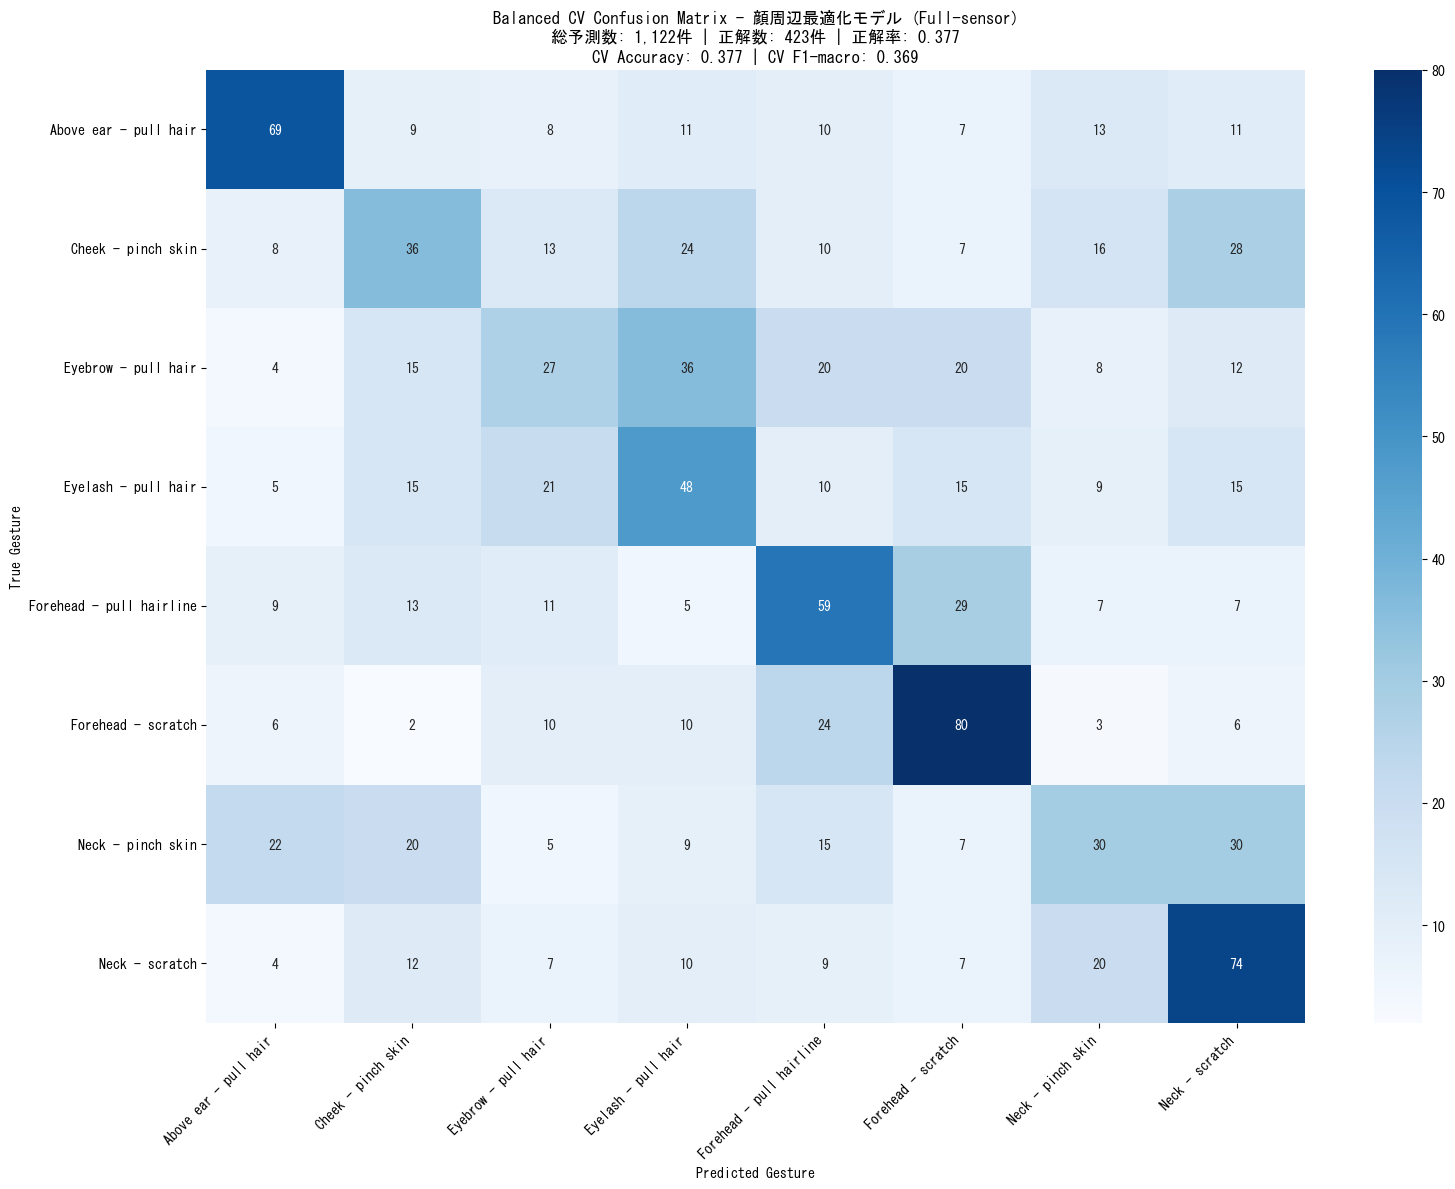


=== クラス別詳細統計 ===
Gesture                             真の件数     予測件数     正解件数     再現率      適合率     
-------------------------------------------------------------------------------------
Above ear - pull hair               138      127      69       0.500    0.543   
Cheek - pinch skin                  142      122      36       0.254    0.295   
Eyebrow - pull hair                 142      102      27       0.190    0.265   
Eyelash - pull hair                 138      153      48       0.348    0.314   
Forehead - pull hairline            140      157      59       0.421    0.376   
Forehead - scratch                  141      172      80       0.567    0.465   
Neck - pinch skin                   138      106      30       0.217    0.283   
Neck - scratch                      143      183      74       0.517    0.404   

=== 全体サマリー ===
総予測数: 1,122件
総正解数: 423件
総誤答数: 699件
正解率: 0.377 (37.7%)

=== 最も混同しやすいジェスチャーペア（上位5位） ===
真のジェスチャー                            予測されたジェスチャー                  

In [49]:
# 顔周辺モデル（8分類）- Full-sensor
face_model_opt_full = create_optimized_group_model(8, "Face-Optimized-Full")

print("顔周辺最適化モデル (Full-sensor) 学習中...")
(cm_face_opt_full, y_true_face_opt_full, y_pred_face_opt_full,
 trained_face_opt_full, face_opt_full_results) = balanced_cv_confusion_matrix_with_model(
    face_model_opt_full, X_face_full_opt, y_face_full, groups_face_full,
    "顔周辺最適化モデル (Full-sensor)", face_gestures, n_folds=CFG.n_folds
)

### Others

その他最適化モデル (IMU-only) 学習中...
=== その他最適化モデル (IMU-only) バランスCV混同行列 (n_folds=5) ===
データサイズ: (1050, 227)
被験者グループ数: 81
Fold 1: Train=840, Val=210
  Accuracy: 0.890, F1-macro: 0.889, Time: 1.2s
Fold 2: Train=840, Val=210
  Accuracy: 0.890, F1-macro: 0.888, Time: 1.3s
Fold 3: Train=838, Val=212
  Accuracy: 0.854, F1-macro: 0.854, Time: 1.3s
Fold 4: Train=841, Val=209
  Accuracy: 0.880, F1-macro: 0.879, Time: 1.3s
Fold 5: Train=841, Val=209
  Accuracy: 0.833, F1-macro: 0.832, Time: 1.2s

=== CV結果 ===
CV精度: 0.870
CV F1-macro: 0.870
CV実行時間: 6.3s


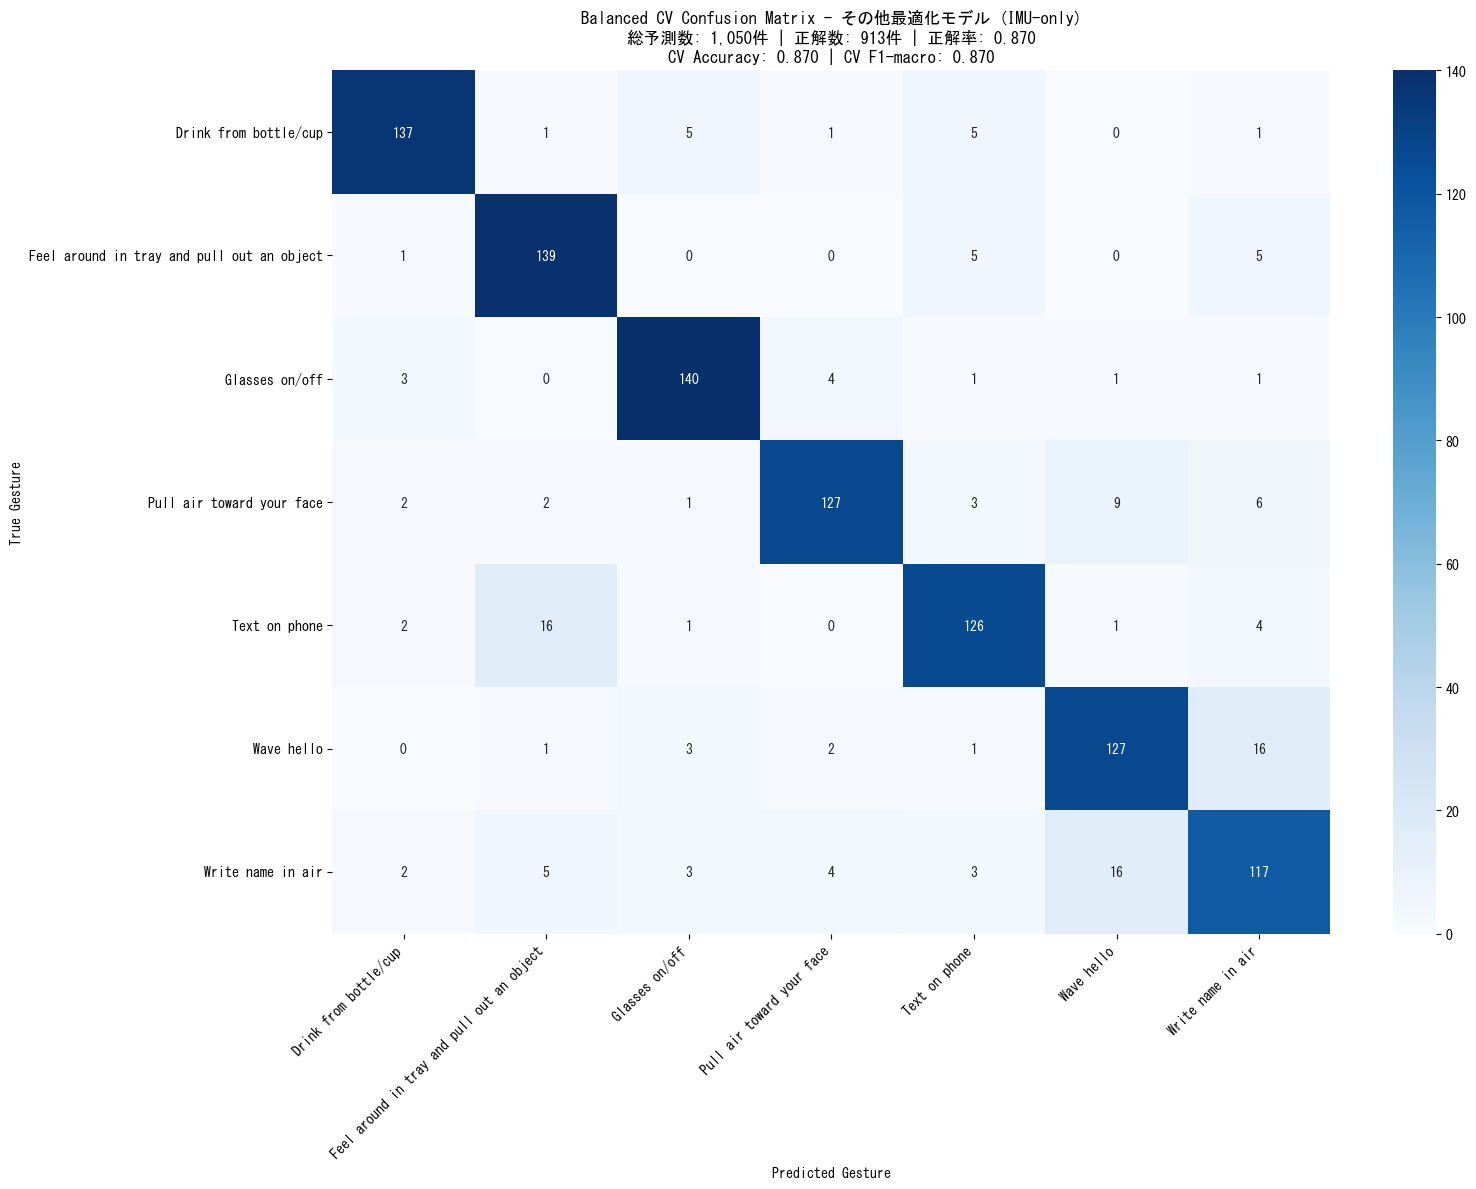


=== クラス別詳細統計 ===
Gesture                             真の件数     予測件数     正解件数     再現率      適合率     
-------------------------------------------------------------------------------------
Drink from bottle/cup               150      147      137      0.913    0.932   
Feel around in tray and pull out an object 150      164      139      0.927    0.848   
Glasses on/off                      150      153      140      0.933    0.915   
Pull air toward your face           150      138      127      0.847    0.920   
Text on phone                       150      144      126      0.840    0.875   
Wave hello                          150      154      127      0.847    0.825   
Write name in air                   150      150      117      0.780    0.780   

=== 全体サマリー ===
総予測数: 1,050件
総正解数: 913件
総誤答数: 137件
正解率: 0.870 (87.0%)

=== 最も混同しやすいジェスチャーペア（上位5位） ===
真のジェスチャー                            予測されたジェスチャー                         誤分類件数      誤分類率    
-----------------------------------------------

In [54]:
# その他モデル（7分類）- IMU-only
other_model_opt_imu = create_optimized_group_model(7, "Other-Optimized-IMU")

print("その他最適化モデル (IMU-only) 学習中...")
(cm_other_opt_imu, y_true_other_opt_imu, y_pred_other_opt_imu,
 trained_other_opt_imu, other_opt_imu_results) = balanced_cv_confusion_matrix_with_model(
    other_model_opt_imu, X_other_imu_opt, y_other_imu, groups_other_imu,
    "その他最適化モデル (IMU-only)", other_gestures, n_folds=CFG.n_folds
)

その他最適化モデル (Full-sensor) 学習中...
=== その他最適化モデル (Full-sensor) バランスCV混同行列 (n_folds=5) ===
データサイズ: (981, 351)
被験者グループ数: 77
Fold 1: Train=786, Val=195
  Accuracy: 0.877, F1-macro: 0.874, Time: 1.7s
Fold 2: Train=786, Val=195
  Accuracy: 0.908, F1-macro: 0.906, Time: 1.7s
Fold 3: Train=780, Val=201
  Accuracy: 0.891, F1-macro: 0.889, Time: 1.7s
Fold 4: Train=785, Val=196
  Accuracy: 0.878, F1-macro: 0.875, Time: 1.7s
Fold 5: Train=787, Val=194
  Accuracy: 0.830, F1-macro: 0.829, Time: 1.7s

=== CV結果 ===
CV精度: 0.877
CV F1-macro: 0.876
CV実行時間: 8.6s


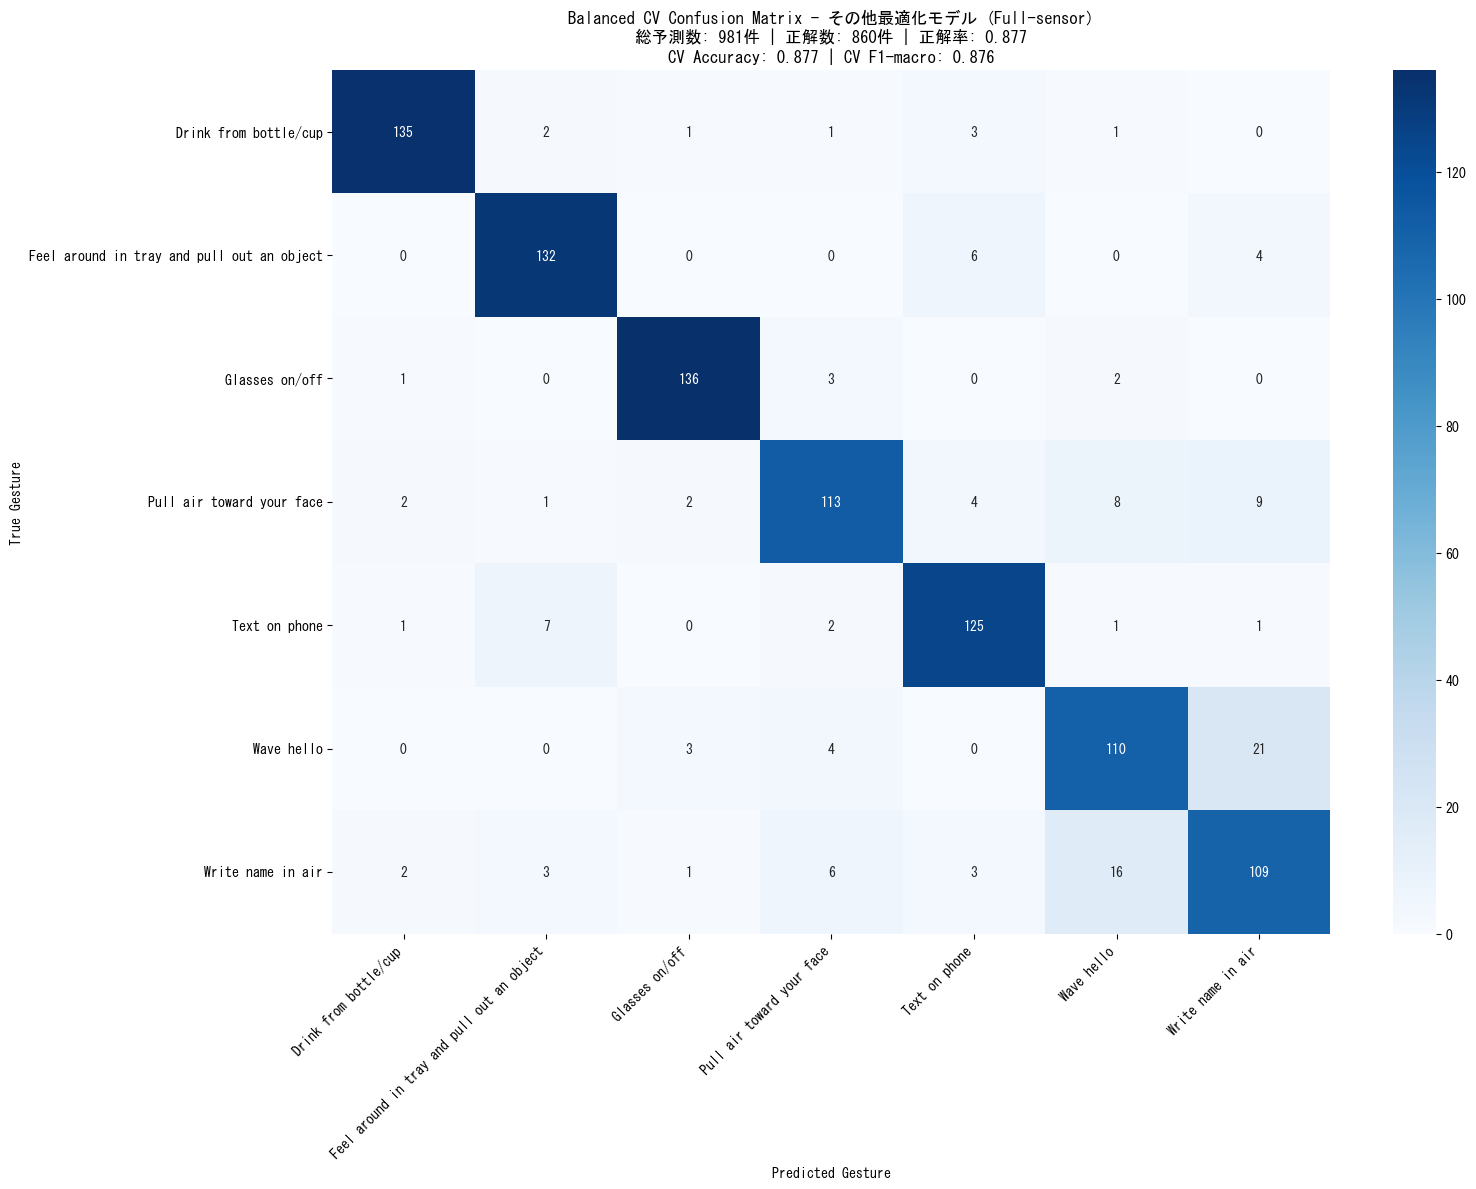


=== クラス別詳細統計 ===
Gesture                             真の件数     予測件数     正解件数     再現率      適合率     
-------------------------------------------------------------------------------------
Drink from bottle/cup               143      141      135      0.944    0.957   
Feel around in tray and pull out an object 142      145      132      0.930    0.910   
Glasses on/off                      142      143      136      0.958    0.951   
Pull air toward your face           139      129      113      0.813    0.876   
Text on phone                       137      141      125      0.912    0.887   
Wave hello                          138      138      110      0.797    0.797   
Write name in air                   140      144      109      0.779    0.757   

=== 全体サマリー ===
総予測数: 981件
総正解数: 860件
総誤答数: 121件
正解率: 0.877 (87.7%)

=== 最も混同しやすいジェスチャーペア（上位5位） ===
真のジェスチャー                            予測されたジェスチャー                         誤分類件数      誤分類率    
-------------------------------------------------

In [55]:
# その他モデル（7分類）- Full-sensor
other_model_opt_full = create_optimized_group_model(7, "Other-Optimized-Full")

print("その他最適化モデル (Full-sensor) 学習中...")
(cm_other_opt_full, y_true_other_opt_full, y_pred_other_opt_full,
 trained_other_opt_full, other_opt_full_results) = balanced_cv_confusion_matrix_with_model(
    other_model_opt_full, X_other_full_opt, y_other_full, groups_other_full,
    "その他最適化モデル (Full-sensor)", other_gestures, n_folds=CFG.n_folds
)

In [63]:
# ========================================
# 顔周辺ジェスチャー専用ハイパーパラメータ最適化
# ========================================

def create_face_gesture_optimization_objective(X, y, groups, n_folds=3):
    """
    顔周辺ジェスチャー専用のOptuna目的関数
    """
    def objective(trial):
        # ハイパーパラメータ探索範囲（顔周辺8分類に特化）
        params = {
            'objective': 'multiclass',
            'num_class': 8,
            'metric': 'multi_logloss',
            'boosting_type': 'gbdt',
            
            # 学習パラメータ（より慎重に）
            'n_estimators': trial.suggest_int('n_estimators', 300, 1000, step=50),
            'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.1, log=True),
            
            # 木構造パラメータ（8分類の複雑さに対応）
            'num_leaves': trial.suggest_int('num_leaves', 20, 100, step=5),
            'max_depth': trial.suggest_int('max_depth', 5, 15),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 50, step=5),
            
            # 特徴量サンプリング（過学習防止）
            'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0, step=0.05),
            'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0, step=0.05),
            'bagging_freq': trial.suggest_int('bagging_freq', 1, 5),
            
            # 正則化（重要）
            'lambda_l1': trial.suggest_float('lambda_l1', 0.0, 1.0, step=0.1),
            'lambda_l2': trial.suggest_float('lambda_l2', 0.0, 1.0, step=0.1),
            
            # その他
            'random_state': CFG.seed,
            'verbose': -1
        }
        
        # GPU利用可能なら使用
        try:
            params.update({
                'device': 'gpu',
                'gpu_platform_id': 0,
                'gpu_device_id': 0
            })
        except:
            params['device'] = 'cpu'
        
        # クロスバリデーション評価
        cv_scores = []
        for fold, (train_idx, val_idx) in enumerate(GroupKFold(n_splits=n_folds).split(X, y, groups)):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
            
            model = LGBMClassifier(**params)
            model.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
                eval_metric='multi_logloss',
                callbacks=[early_stopping(100, verbose=False)]
            )
            
            y_pred = model.predict(X_val)
            f1 = f1_score(y_val, y_pred, average='macro')
            cv_scores.append(f1)
        
        return np.mean(cv_scores)
    
    return objective

print("=" * 80)
print("顔周辺ジェスチャー専用ハイパーパラメータ最適化")
print("=" * 80)

# Optuna最適化実行
print("Optuna最適化を開始...")
study = optuna.create_study(direction='maximize', 
                           sampler=optuna.samplers.TPESampler(seed=CFG.seed))

objective = create_face_gesture_optimization_objective(
    X_face_full_opt, y_face_full, groups_face_full, n_folds=3
)

study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n=== 最適化結果 ===")
print(f"最高F1スコア: {study.best_value:.4f}")
print(f"最適パラメータ:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# 最適パラメータでモデル作成
best_params = study.best_params.copy()
best_params.update({
    'objective': 'multiclass',
    'num_class': 8,
    'random_state': CFG.seed,
    'verbose': -1
})

optimized_face_model = LGBMClassifier(**best_params)

[I 2025-07-21 17:25:53,278] A new study created in memory with name: no-name-41334572-0a65-4da1-8c7d-a838789e1738


顔周辺ジェスチャー専用ハイパーパラメータ最適化
Optuna最適化を開始...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-07-21 17:26:13,189] Trial 0 finished with value: 0.33311035327362143 and parameters: {'n_estimators': 550, 'learning_rate': 0.09237421878009823, 'num_leaves': 80, 'max_depth': 11, 'min_child_samples': 15, 'feature_fraction': 0.65, 'bagging_fraction': 0.6, 'bagging_freq': 5, 'lambda_l1': 0.6000000000000001, 'lambda_l2': 0.7000000000000001}. Best is trial 0 with value: 0.33311035327362143.
[I 2025-07-21 17:26:31,627] Trial 1 finished with value: 0.34481081629189053 and parameters: {'n_estimators': 300, 'learning_rate': 0.09527257190058894, 'num_leaves': 90, 'max_depth': 7, 'min_child_samples': 15, 'feature_fraction': 0.65, 'bagging_fraction': 0.7, 'bagging_freq': 3, 'lambda_l1': 0.4, 'lambda_l2': 0.30000000000000004}. Best is trial 1 with value: 0.34481081629189053.
[I 2025-07-21 17:27:02,450] Trial 2 finished with value: 0.341605497178989 and parameters: {'n_estimators': 750, 'learning_rate': 0.025034102152280427, 'num_leaves': 40, 'max_depth': 9, 'min_child_samples': 30, 'featu

In [ ]:
# ========================================
# 最適化モデルの評価
# ========================================

print("最適化された顔周辺モデルの評価...")

# 最適化モデルの学習・評価
(cm_face_optimized, y_true_face_opt, y_pred_face_opt,
 trained_face_optimized, face_optimized_results) = balanced_cv_confusion_matrix_with_model(
    optimized_face_model, X_face_full_opt, y_face_full, groups_face_full,
    "顔周辺最適化モデル (Optuna)", face_gestures, n_folds=CFG.n_folds
)

# 改善度分析
def analyze_optimization_impact():
    """
    最適化による改善度分析
    """
    print(f"\n=== 最適化による改善度分析 ===")
    
    # 元モデル vs 最適化モデル
    original_acc = face_opt_full_results['cv_accuracy']
    optimized_acc = face_optimized_results['cv_accuracy']
    
    original_f1 = face_opt_full_results['cv_f1_macro']
    optimized_f1 = face_optimized_results['cv_f1_macro']
    
    acc_improvement = optimized_acc - original_acc
    f1_improvement = optimized_f1 - original_f1
    
    print(f"{'指標':<15} {'元モデル':<10} {'最適化後':<10} {'改善':<10} {'改善率':<10}")
    print("-" * 60)
    print(f"{'正解率':<15} {original_acc:<10.3f} {optimized_acc:<10.3f} {acc_improvement:<10.3f} {acc_improvement/original_acc*100:+<10.1f}%")
    print(f"{'F1-macro':<15} {original_f1:<10.3f} {optimized_f1:<10.3f} {f1_improvement:<10.3f} {f1_improvement/original_f1*100:+<10.1f}%")
    
    # 期待される階層分類全体への影響
    face_data_ratio = len(y_face_full) / len(y_full_bal)
    hierarchical_improvement = face_data_ratio * acc_improvement
    
    print(f"\n階層分類全体への期待影響:")
    print(f"  顔周辺データ比率: {face_data_ratio:.1%}")
    print(f"  全体精度への寄与: +{hierarchical_improvement:.3f}")
    
    return {
        'original_accuracy': original_acc,
        'optimized_accuracy': optimized_acc,
        'improvement': acc_improvement,
        'improvement_rate': acc_improvement/original_acc*100
    }

optimization_impact = analyze_optimization_impact()

# Compare performance

In [61]:
# ========================================
# 第二段階モデル性能総合評価
# ========================================

def summarize_second_stage_performance():
    """
    第二段階モデルの総合性能評価
    """
    print("=" * 80)
    print("第二段階専門モデル 総合性能サマリー")
    print("=" * 80)
    
    # 結果データ収集
    results_summary = {
        'IMU-only': {
            '足回り (3分類)': leg_opt_imu_results['cv_accuracy'],
            '顔周辺 (8分類)': face_opt_imu_results['cv_accuracy'],
            'その他 (7分類)': other_opt_imu_results['cv_accuracy']
        },
        'Full-sensor': {
            '足回り (3分類)': leg_opt_full_results['cv_accuracy'],
            '顔周辺 (8分類)': face_opt_full_results['cv_accuracy'],
            'その他 (7分類)': other_opt_full_results['cv_accuracy']
        }
    }
    
    print(f"{'グループ':<15} {'IMU-only':<12} {'Full-sensor':<12} {'Full優位':<10}")
    print("-" * 60)
    
    for group in ['足回り (3分類)', '顔周辺 (8分類)', 'その他 (7分類)']:
        imu_acc = results_summary['IMU-only'][group]
        full_acc = results_summary['Full-sensor'][group]
        advantage = full_acc - imu_acc
        
        print(f"{group:<15} {imu_acc:<12.3f} {full_acc:<12.3f} {advantage:<10.3f}")
    
    # グループ別データ分布での重み付き平均精度計算
    group_distributions = {
        'IMU-only': {
            0: len(y_face_imu) / len(y_imu_bal),    # 顔周辺比率
            1: len(y_leg_imu) / len(y_imu_bal),     # 足回り比率
            2: len(y_other_imu) / len(y_imu_bal)    # その他比率
        },
        'Full-sensor': {
            0: len(y_face_full) / len(y_full_bal),
            1: len(y_leg_full) / len(y_full_bal),
            2: len(y_other_full) / len(y_full_bal)
        }
    }
    
    print(f"\n=== 期待される階層分類全体精度 ===")
    print("第一段階精度 × 各グループ精度の重み付き平均")
    
    for sensor_type in ['IMU-only', 'Full-sensor']:
        # 第一段階精度
        stage1_acc = group_imu_results['cv_accuracy'] if sensor_type == 'IMU-only' else group_full_results['cv_accuracy']
        
        # 第二段階重み付き精度
        stage2_weighted_acc = (
            group_distributions[sensor_type][0] * results_summary[sensor_type]['顔周辺 (8分類)'] +
            group_distributions[sensor_type][1] * results_summary[sensor_type]['足回り (3分類)'] +
            group_distributions[sensor_type][2] * results_summary[sensor_type]['その他 (7分類)']
        )
        
        # 統合精度
        hierarchical_acc = stage1_acc * stage2_weighted_acc
        
        # 元の18分類精度と比較
        original_acc = imu_results['cv_accuracy'] if sensor_type == 'IMU-only' else full_results['cv_accuracy']
        improvement = hierarchical_acc - original_acc
        improvement_pct = (improvement / original_acc * 100) if original_acc > 0 else 0
        
        print(f"\n{sensor_type}:")
        print(f"  第一段階精度: {stage1_acc:.3f}")
        print(f"  第二段階重み付き精度: {stage2_weighted_acc:.3f}")
        print(f"  期待統合精度: {hierarchical_acc:.3f}")
        print(f"  元の18分類精度: {original_acc:.3f}")
        print(f"  期待改善: +{improvement:.3f} ({improvement_pct:+.1f}%)")

# 総合評価実行
summarize_second_stage_performance()

第二段階専門モデル 総合性能サマリー
グループ            IMU-only     Full-sensor  Full優位    
------------------------------------------------------------
足回り (3分類)       0.593        0.575        -0.018    
顔周辺 (8分類)       0.318        0.377        0.059     
その他 (7分類)       0.870        0.877        0.007     

=== 期待される階層分類全体精度 ===
第一段階精度 × 各グループ精度の重み付き平均

IMU-only:
  第一段階精度: 0.916
  第二段階重み付き精度: 0.579
  期待統合精度: 0.530
  元の18分類精度: 0.537
  期待改善: +-0.007 (-1.3%)

Full-sensor:
  第一段階精度: 0.948
  第二段階重み付き精度: 0.604
  期待統合精度: 0.573
  元の18分類精度: 0.561
  期待改善: +0.011 (+2.0%)
